# Name : Pranav Tapdiya (08)
# Name : Prathamesh Rathod (10)
# Section C
# Project : Youtube Channel Analysis

# YouTube Channel Analysis

## Table of Contents

1. Overview and Problem Statement  
2. Reading the Data  
3. Exploratory Data Analysis  
    - Data Cleaning & Descriptive Statistics
    - Audience Demographics & Engagement
    - Video Performance Metrics
    - Correlation Analysis
4. Sentiment Analysis  
    - Text Preprocessing
    - Polarity-Based Sentiment Analysis
    - BERT-Based Sentiment Analysis
    - Word Cloud Visualization
    - Most/Least Commented Videos
5. Content Strategy Insights
    - Most Engaging Content
    - Growth-Driving Content
6. Summary  

---

## Overview and Problem Statement

In this project, we analyze data from **Ken Jee’s YouTube channel**, covering the period from November 2017 to January 2022. The dataset contains four files that provide detailed insights into the channel’s performance over time.

The main goal is to understand what drives growth and engagement on the channel, and to provide actionable insights for content strategy.

We start by exploring the **comments section** to identify common themes and understand what viewers are discussing, employing both traditional polarity-based and advanced BERT-based sentiment analysis.

Next, we examine **video titles and thumbnails** to see which types are more effective in attracting viewers and driving watch time.

We also analyze the **core audience**, including their preferences, geographical distribution, and engagement patterns (subscribed vs. unsubscribed viewers).

Another important part of this study is identifying which videos contributed the most to the channel’s **growth and success** in terms of subscriber gains.

Finally, we look at what kind of content generates the highest **engagement** and longest watch times, helping us understand what keeps viewers interested.

The dataset includes performance metrics, audience details (such as country and subscriber status), and daily video data. It was collected using YouTube’s API and analytics tools, while ensuring user privacy.

Overall, this comprehensive analysis helps uncover useful insights for improving content strategy and growing a YouTube channel by understanding audience preferences and content performance.

In [19]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from wordcloud import WordCloud
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (22, 5)
plt.rcParams['figure.dpi'] = 100

Now that we have imported all the required libraries and the classes, we start reading the Data with the help of pandas and taking a look at the data.

<a id = Section2></a>

<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Reading the Data
    
</h2>
</div>
    
</center>

In [21]:
Aggregated_df = pd.read_csv('Aggregated_Metrics_By_Video.csv')
Country_df = pd.read_csv('Aggregated_Metrics_By_Country_And_Subscriber_Status.csv')
Video_df = pd.read_csv('Video_Performance_Over_Time.csv')
Comments_df = pd.read_csv('All_Comments_Final.csv')

In [22]:
Aggregated_df.head()

,Video,Video title,Video pub­lish time,Com­ments ad­ded,Shares,Dis­likes,Likes,Sub­scribers lost,Sub­scribers gained,RPM (USD),CPM (USD),Av­er­age per­cent­age viewed (%),Av­er­age view dur­a­tion,Views,Watch time (hours),Sub­scribers,Your es­tim­ated rev­en­ue (USD),Im­pres­sions,Im­pres­sions click-through rate (%)
0,Total,NaN,NaN,14197,39640,3902,225021,45790,229241,5.276,11.990,26.61,0:03:25,5568487,317602.3536,183451,29068.652,100954064,3.16
1,4OZip0cgOho,How I Would Learn Data Science (If I Had to St...,"May 8, 2020",907,9583,942,46903,451,46904,6.353,12.835,36.65,0:03:09,1253559,65850.7042,46453,7959.533,26498799,3.14
2,78LjdAAw0wA,100K Channel Update + AMA Stream!,"Nov 12, 2020",412,4,4,130,15,12,2.668,6.259,6.26,0:05:14,2291,200.2966,-3,6.113,188318,0.72
3,hO_YKK_0Qck,Uber Driver to Machine Learning Engineer in 9 ...,"Jul 16, 2020",402,152,15,881,9,198,9.516,11.695,15.12,0:10:21,21350,3687.3387,189,202.963,442334,2.53
4,uXLnbdHMf8w,Why I'm Starting Data Science Over Again.,"Aug 29, 2020",375,367,22,2622,40,1957,3.143,7.943,33.41,0:02:36,49564,2148.3110,1917,155.779,521185,4.01


In [23]:
Country_df.head()

,Video Title,External Video ID,Video Length,Thumbnail link,Country Code,Is Subscribed,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
0,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,HK,True,23,1,0,0,2,0,0.671870,39.640348,0
1,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,ME,True,3,0,0,0,0,0,0.498870,29.433333,0
2,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,RW,True,2,0,0,0,0,0,0.681780,40.225000,0
3,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,US,True,979,81,6,8,16,4,0.694854,40.996389,0
4,🌶 Hot Topics in Tech: Data Science Explained #...,OtqQYqRNDGI,59,https://i.ytimg.com/vi/OtqQYqRNDGI/hqdefault.jpg,DE,False,75,3,0,1,0,0,0.661515,39.029373,0


In [24]:
Video_df.head()

,Date,Video Title,External Video ID,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
0,19 Jan 2022,Kaggle Project From Scratch - Part 2 (Explorat...,KQ80oD_boBM,2191,https://i.ytimg.com/vi/KQ80oD_boBM/hqdefault.jpg,13,0,0,0,0,0,0.069055,151.300154,0
1,19 Jan 2022,Welcome To My Channel | Ken Jee | Data Science,smeFkHwnM_k,51,https://i.ytimg.com/vi/smeFkHwnM_k/hqdefault.jpg,2,0,0,0,1,0,0.471255,24.034000,0
2,19 Jan 2022,How She Dominated the FAANG Data Science Inter...,vfV4nm004VQ,2686,https://i.ytimg.com/vi/vfV4nm004VQ/hqdefault.jpg,10,0,0,0,0,0,0.126049,338.567500,0
3,19 Jan 2022,The 9 Books That Changed My Perspective in 2019,3TrAYmrmA8o,980,https://i.ytimg.com/vi/3TrAYmrmA8o/hqdefault.jpg,1,0,0,0,0,0,0.011508,11.278000,0
4,19 Jan 2022,Interview with the Director of AI Research @ N...,Xgg7dIKys9E,2904,https://i.ytimg.com/vi/Xgg7dIKys9E/hqdefault.jpg,1,0,0,0,0,0,0.007541,21.900000,0


In [25]:
Comments_df.head()

,Comments,Comment_ID,Reply_Count,Like_Count,Date,VidId,user_ID
0,Thanks for this video Ken.\n\nI decided to go ...,UgxFZTIzC4UPyhhX_PZ4AaABAg,0,0,2022-01-22T08:13:29Z,xpIFS6jZbe8,user_981
1,Hello ken jee!!! I'm doing a graduation on Com...,Ugx3IYuAufhb932GYQx4AaABAg,0,0,2022-01-22T01:09:46Z,xpIFS6jZbe8,user_213
2,"Thanks for this video, man. So useful. I'll me...",UgyhwwoK24arzRt1mud4AaABAg,0,0,2022-01-21T23:59:05Z,rEWPqw6rMGI,user_1065
3,Great video!!! I started learning Python 8 mon...,UgwrrI7nd3WClsotmHV4AaABAg,0,0,2022-01-21T23:00:37Z,xpIFS6jZbe8,user_3391
4,Been watching hours of your material (and Tina...,UgxlOrHO4MHKSwY9mUN4AaABAg,0,0,2022-01-21T20:24:20Z,sHRq-LshG3U,user_2816


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing the dataset to understand its structure, patterns, and key insights before applying machine learning models.

In this project, EDA is used to analyze YouTube video performance and audience engagement.

---

### Objectives of EDA

- Understand the dataset structure  
- Identify patterns in views, likes, and comments  
- Detect any missing or inconsistent data  
- Prepare data for further NLP analysis  

---

### Key Steps Performed

#### 1. Data Cleaning
- Handled missing values  
- Removed unnecessary or duplicate data  
- Ensured dataset consistency  

---

#### 2. Descriptive Analysis
- Calculated basic statistics like mean, median, and distribution  
- Analyzed metrics such as views, likes, and comments  

---

#### 3. Data Visualization
- Used histograms to understand distribution  
- Used bar charts to compare video performance  
- Used heatmaps to analyze feature relationships  

---

#### 4. Correlation Analysis
- Studied relationships between views, likes, and comments  
- Identified how engagement metrics are related  

---

### Conclusion of EDA

EDA helped in identifying important patterns in video performance and audience engagement.  
These insights were useful for further sentiment analysis and model building.

In [26]:
Aggregated_df.describe()

,Com­ments ad­ded,Shares,Dis­likes,Likes,Sub­scribers lost,Sub­scribers gained,RPM (USD),CPM (USD),Av­er­age per­cent­age viewed (%),Views,Watch time (hours),Sub­scribers,Your es­tim­ated rev­en­ue (USD),Im­pres­sions,Im­pres­sions click-through rate (%)
count,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,222.000000,224.000000,2.240000e+02,224.000000,224.000000,224.000000,2.240000e+02,224.000000
mean,126.750000,353.924107,34.839286,2008.919643,217.620536,1608.084821,4.442040,11.442779,34.087277,4.971645e+04,2835.711522,1390.464286,259.537433,9.013573e+05,3.084152
std,948.732371,2736.321694,268.668317,15387.274015,3058.766918,15628.834115,1.789148,3.334781,15.118746,3.810302e+05,21662.566897,12647.246927,2011.119492,6.967916e+06,1.670448
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.439000,5.230000,6.000000e+01,1.068400,-21.000000,0.000000,3.650000e+02,0.490000
25%,18.000000,19.000000,1.000000,163.500000,2.000000,27.000000,3.220750,9.379500,23.602500,3.940000e+03,177.037125,19.750000,12.208250,9.947100e+04,1.925000
50%,37.000000,46.500000,4.000000,342.500000,7.000000,70.000000,4.334500,11.169500,35.120000,8.347500e+03,397.852200,62.500000,32.595500,1.541925e+05,2.895000
75%,66.250000,114.250000,11.000000,716.000000,14.000000,245.500000,5.372250,12.901000,43.462500,1.836875e+04,1145.621400,230.500000,96.814750,2.894885e+05,3.975000
max,14197.000000,39640.000000,3902.000000,225021.000000,45790.000000,229241.000000,10.387000,37.786000,76.600000,5.568487e+06,317602.353600,183451.000000,29068.652000,1.009541e+08,11.510000


In [27]:
print('Net Subscribers Gained -', Aggregated_df['Sub­scribers gained'].loc[0]-Aggregated_df['Sub­scribers lost'].loc[0])

Net Subscribers Gained - 183451


In [28]:
Video_df.describe()

,Video Length,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
count,111857.000000,111857.000000,111857.000000,111857.000000,111857.000000,111857.000000,111857.000000,110510.000000,110510.000000,111857.0
mean,874.615876,49.714287,2.095533,0.052424,0.086789,1.169180,0.026391,0.350456,216.769428,0.0
std,861.297667,316.557515,14.263695,1.852013,1.793532,12.109065,0.313908,0.232566,190.709651,0.0
min,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,375.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.178010,117.379080,0.0
50%,548.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.336824,181.505000,0.0
75%,917.000000,28.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.476257,268.126888,0.0
max,5029.000000,35677.000000,1610.000000,289.000000,420.000000,1844.000000,32.000000,8.476340,5322.300000,0.0


In [29]:
Country_df.describe()

,Video Length,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
count,55292.000000,55292.000000,55292.000000,55292.000000,55292.000000,55292.000000,55292.000000,53854.000000,53854.000000,55292.0
mean,896.678073,100.573157,4.239311,0.106055,0.175577,2.365279,0.053389,0.347821,205.297156,0.0
std,927.380801,1704.966002,65.291451,2.507351,3.601171,65.889539,0.766945,0.259734,206.542106,0.0
min,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,375.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.145948,85.442891,0.0
50%,545.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.320983,170.139725,0.0
75%,934.000000,27.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.486153,259.449958,0.0
max,5029.000000,285593.000000,9165.000000,399.000000,436.000000,9599.000000,103.000000,4.967797,5027.660000,0.0


<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: lightgray;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 10px;
              color:black;">Analysis
    
</h3>
</div>
    
</center>

1. Over the past six years, Ken has published a total of 223 videos, amassing an impressive 39640 shares, 225,021 likes, and gaining 183,451 new subscribers.
2. On average, Ken receives 126 comments on each of his videos, reflecting active engagement from his viewers.
3. Across his 223 video uploads, the average watch time amounts to 2835 hours, indicative of the captivating content Ken consistently delivers to his audience.

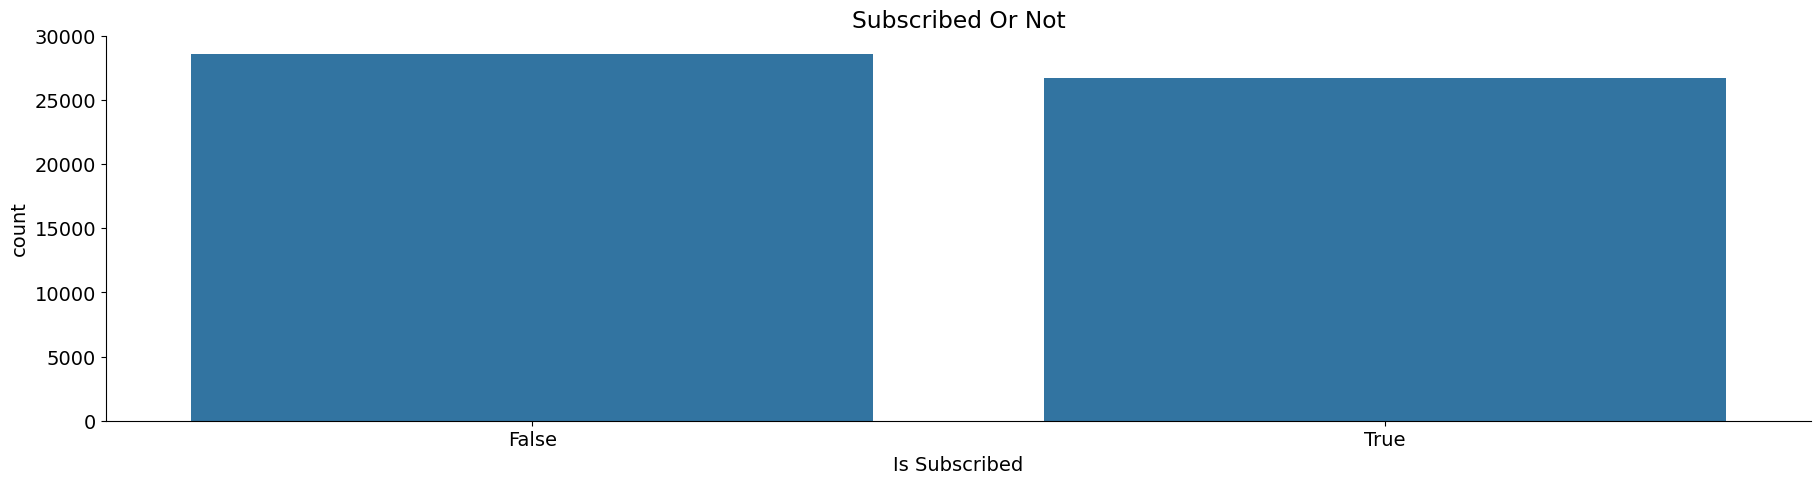

In [30]:
Subscribed_df = Country_df.copy().sort_values(by='Views',ascending= False)
plt.title("Subscribed Or Not")
sns.countplot(x= Subscribed_df['Is Subscribed'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [31]:
True_df = Country_df[Country_df['Is Subscribed'].eq(True)].sort_values(by='Views',ascending= False)
False_df = Country_df[Country_df['Is Subscribed'].eq(False)].sort_values(by='Views',ascending= False)
True_df['Video Title'].head(10).unique().tolist()

['How I Would Learn Data Science (If I Had to Start Over)',
 'The Best Free Data Science Courses Nobody is Talking About',
 '3 Proven Data Science Projects for Beginners (Kaggle)',
 'Beginner Kaggle Data Science Project Walk-Through (Titanic)',
 'Data Science Project from Scratch - Part 1 (Project Planning)',
 'The Projects You Should Do To Get A Data Science Job']


<b>INTERPRETATION: </b> Above are the videos that are most watched by people who have subsribed to the channel.

</div>
  </center>

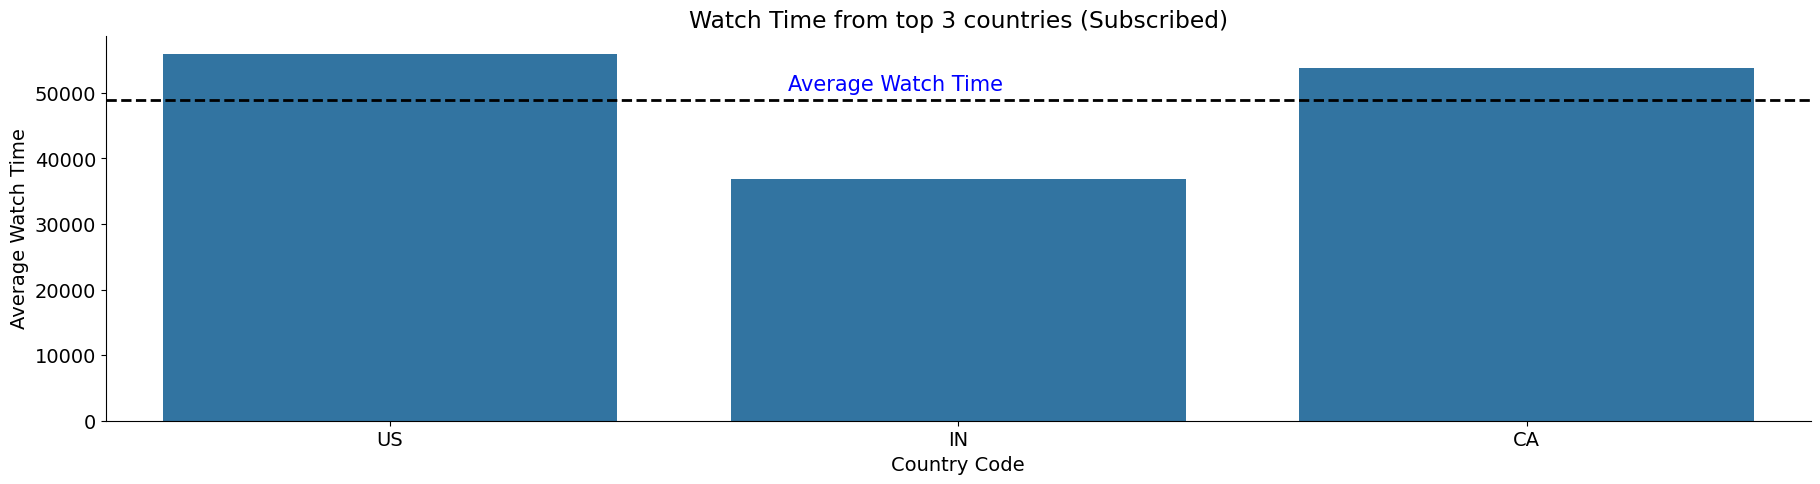

In [32]:
Subscribed_Watchtime = True_df.groupby('Country Code').sum().sort_values(by='Views',ascending= False).head(3).reset_index()
sns.barplot(x=Subscribed_Watchtime['Country Code'], y= Subscribed_Watchtime['Average Watch Time'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title("Watch Time from top 3 countries (Subscribed)")
plt.axhline(Subscribed_Watchtime['Average Watch Time'].mean(), linestyle='--', lw=2, zorder=1, color='black')
plt.annotate(f'Average Watch Time', (0.7, Subscribed_Watchtime['Average Watch Time'].mean()+1500), fontsize=15, color='blue')

plt.xlabel('Country Code')
plt.show()


<b>INTERPRETATION: </b> People who have subscribed to the channel are from US and Great Britain and contribute to the highest Average Watch Time.

</div>
  </center>

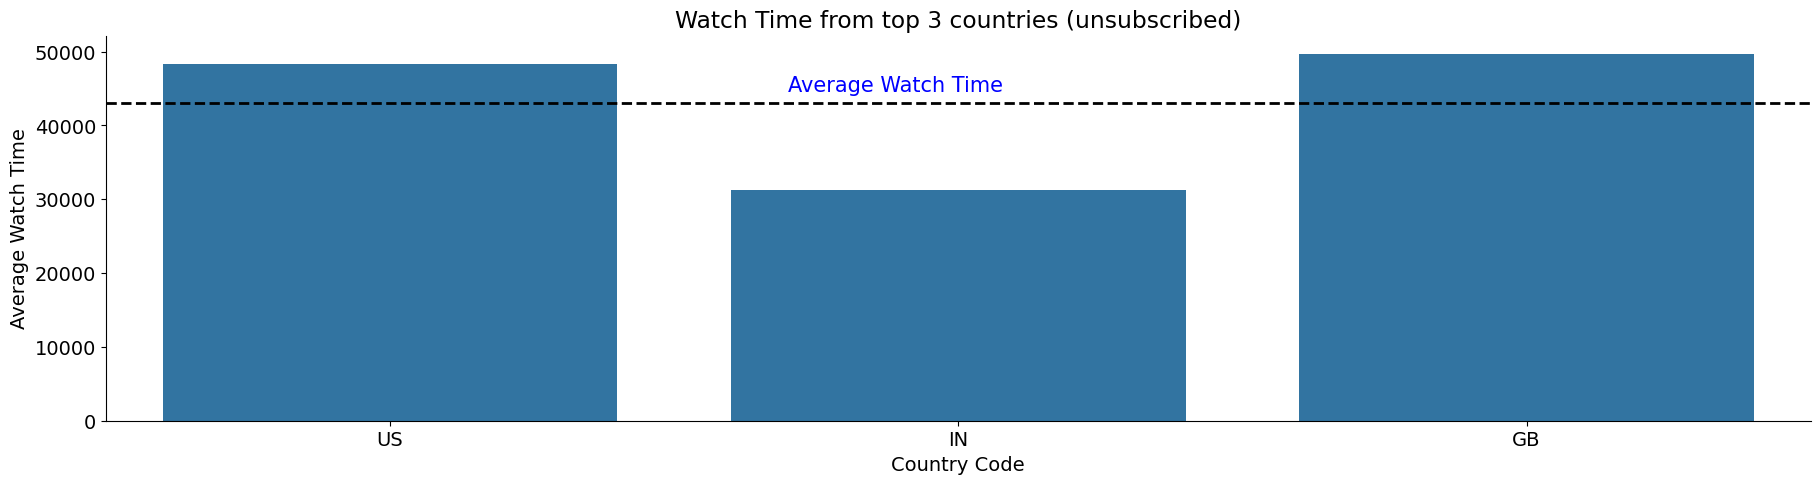

In [33]:
unsubscribed_Watchtime = False_df.groupby('Country Code').sum().sort_values(by='Views',ascending= False).head(3).reset_index()
sns.barplot(data=unsubscribed_Watchtime, x=unsubscribed_Watchtime['Country Code'],
            y= unsubscribed_Watchtime['Average Watch Time'])

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.axhline(unsubscribed_Watchtime['Average Watch Time'].mean(), linestyle='--', lw=2, zorder=1, color='black')
plt.annotate(f'Average Watch Time', (0.7, unsubscribed_Watchtime['Average Watch Time'].mean()+1500), fontsize=15, color='blue')

plt.title("Watch Time from top 3 countries (unsubscribed)")
plt.xlabel('Country Code')
plt.show()


<b>INTERPRETATION: </b> The most amount of watchtime from the unsubscribed viewers come from Britain then US and then India.

</div>
  </center>

In [34]:
False_df['Video Title'].head(12).unique().tolist()

['How I Would Learn Data Science (If I Had to Start Over)',
 'The Best Free Data Science Courses Nobody is Talking About',
 '3 Proven Data Science Projects for Beginners (Kaggle)',
 'Data Science Certificate vs Bootcamp vs Masters Degree',
 "Why You Probably Won't Become a Data Scientist"]

## Model Training and Evaluation

In this step, multiple machine learning models are trained to perform sentiment classification on the text data.

The models used in this project are:
- Logistic Regression  
- Naive Bayes  
- Random Forest  

These models are trained using TF-IDF features extracted from the text data.

---

### Evaluation Metrics

To compare model performance, the following metrics are used:
- Accuracy  
- Precision  
- Recall  
- F1-score  

A confusion matrix is also plotted to visualize the performance of the best model.

---

### Model Training and Comparison

Logistic Regression Accuracy: 0.8442
Naive Bayes Accuracy: 0.6973
Random Forest Accuracy: 0.8110

Model Comparison Table:
                 Model  Accuracy
0  Logistic Regression  0.844238
1          Naive Bayes  0.697266
2        Random Forest  0.811035


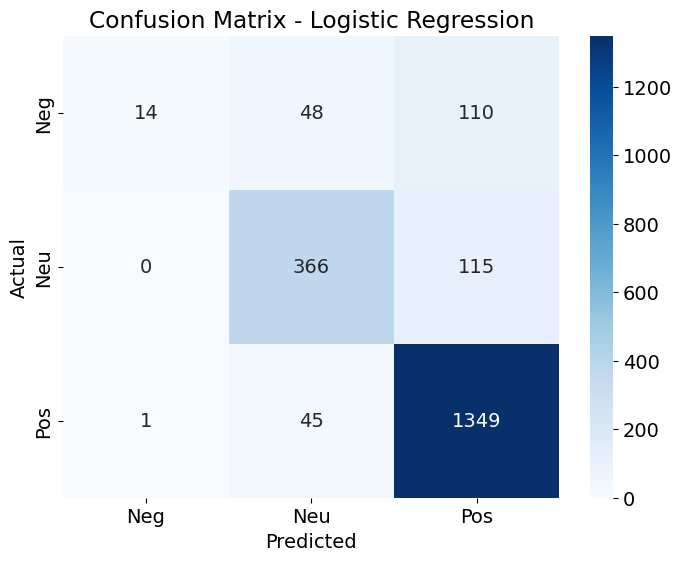

In [35]:
import re
import pandas as pd
from textblob import TextBlob
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Ensure column names are standardized before use
Comments_df.columns = Comments_df.columns.str.strip().str.lower()

# Define clean_text function
def clean_text(text):
    if not isinstance(text, str):
        return "" # Handle non-string inputs by returning an empty string
    # Convert text to lowercase
    text = text.lower().strip()
    # Remove common punctuation marks and special characters using regex
    text = re.sub(r"[-()\"#/@;:<>{}`+=~|.!?,']", "", text)
    # Replace multiple spaces with a single space
    text = re.sub(r"[ ]+", " ", text)
    # Remove double newlines
    text = re.sub('\n\n','', text)
    # Strip leading/trailing whitespace again
    text = text.rstrip().strip()
    return text

# Apply text cleaning and create 'clean comments' column
clean_comments = []
for i in range(len(Comments_df['comments'])):
    clean_comments.append(clean_text(Comments_df['comments'][i]))
Comments_df['clean comments'] = clean_comments

# Calculate polarity and create 'polarity' and 'sentiment' columns
polarity = []
for i in Comments_df['clean comments']:
    blob = TextBlob(i)
    polarity.append(round(blob.sentiment.polarity,3))
Comments_df['polarity'] = polarity

sentiment = []
for p in Comments_df['polarity']:
    if p > 0:
        sentiment.append('Positive')
    elif p < 0:
        sentiment.append('Negative')
    else:
        sentiment.append('Neutral')
Comments_df['sentiment'] = sentiment

# Now proceed with model training
text_col = 'clean comments'
sent_col = 'sentiment'

X = Comments_df[text_col].fillna('')
y = Comments_df[sent_col]

y_encoded = y.astype(str).str.strip().str.lower().map({
    'negative': 0,
    'neutral': 1,
    'positive': 2
})

# Remove rows where sentiment could not be mapped (i.e., NaN values after mapping)
y_encoded = y_encoded.dropna()

# Align X with the filtered y_encoded index
X = X[y_encoded.index]

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y_encoded, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, predictions)
    results.append({"Model": name, "Accuracy": acc})
    print(f"{name} Accuracy: {acc:.4f}")

comparison_df = pd.DataFrame(results)
print("\nModel Comparison Table:")
print(comparison_df)

# Select the best model (Logistic Regression based on common performance and speed)
best_model = models["Logistic Regression"]
y_pred = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [36]:
import ipywidgets as widgets
from IPython.display import display

# Load saved assets (BERT tokenizer and model are already loaded
# We no longer need joblib.load for the previous scikit-learn model

# GUI Components
text_input = widgets.Textarea(description='Comment:', placeholder='Type a comment here...')
button = widgets.Button(description='Predict Sentiment (BERT)', button_style='info')
output = widgets.Output()

# Assuming sentiment_score function is defined
def sentiment_score(review):
    tokens = tokenizer.encode(review, return_tensors='pt')
    result = model(tokens)
    return int(torch.argmax(result.logits))+1

def on_button_clicked(b):
    with output:
        output.clear_output()
        comment = text_input.value
        if comment:
            bert_score = sentiment_score(comment)

            # Map BERT's 1-5 score to sentiment labels
            if bert_score <= 2:
                sentiment_label = 'Negative 😡'
            elif bert_score == 3:
                sentiment_label = 'Neutral 😐'
            else: # bert_score is 4 or 5
                sentiment_label = 'Positive 😊'

            print(f"Result (BERT): {sentiment_label} (Score: {bert_score}/5)")
        else:
            print("Please enter a comment.")

button.on_click(on_button_clicked)

# Display GUI
print("--- Sentiment Analysis GUI (BERT) ---")
display(text_input, button, output)

--- Sentiment Analysis GUI (BERT) ---


Textarea(value='', description='Comment:', placeholder='Type a comment here...')

Button(button_style='info', description='Predict Sentiment (BERT)', style=ButtonStyle())

Output()

In [37]:
import joblib

# Saving the best model and tfidf vectorizer
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Model saved successfully.")

Model saved successfully.


### Understanding the `AttributeError: 'BertForSequenceClassification' object has no attribute 'predict'`

The `BertForSequenceClassification` object (loaded from Hugging Face's `transformers` library) does not expose a direct `.predict()` method like traditional `scikit-learn` classifiers. Instead, when you call the model with tokenized inputs (e.g., `model(tokens)`), it returns an object containing `logits`. These `logits` are the raw, unnormalized scores for each possible output class.

To obtain the predicted class label, you need to perform two steps:
1.  **Get the logits**: The `model` output (e.g., `result = model(tokens)`) contains a `logits` attribute (`result.logits`).
2.  **Determine the class from logits**: Use `torch.argmax()` on these logits to find the index of the highest score. This index corresponds to the predicted class. Since the `nlptown/bert-base-multilingual-uncased-sentiment` model outputs scores from 1 to 5, we often add `1` to the `argmax` result to match the intended sentiment scale.

The `sentiment_score` function defined earlier (`ad42252e`) already correctly implements this logic.

In [38]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>




<center>
<div class="alert alert-block alert-info">
<b>INTERPRETATION: </b> Above is the list of videos being watched the most by the unsubscribed viewers.


</div>
  </center>

<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Q. Who is Ken's core audience and what are they interested in?
    
</h2>
</div>
    
</center>

In [39]:

ViewsbyCountry = Country_df[['Country Code', 'Views']].copy().sort_values(by='Views',ascending= False)
ViewsbyCountry.groupby('Country Code').sum().sort_values(by='Views',ascending= False).head(5)

,Views
Country Code,
US,1354450
IN,1155510
GB,239177
CA,222373
DE,172165



<b>INTERPRETATION: </b> People from US, India and Great Britain watch the videos the most.


</div>
  </center>

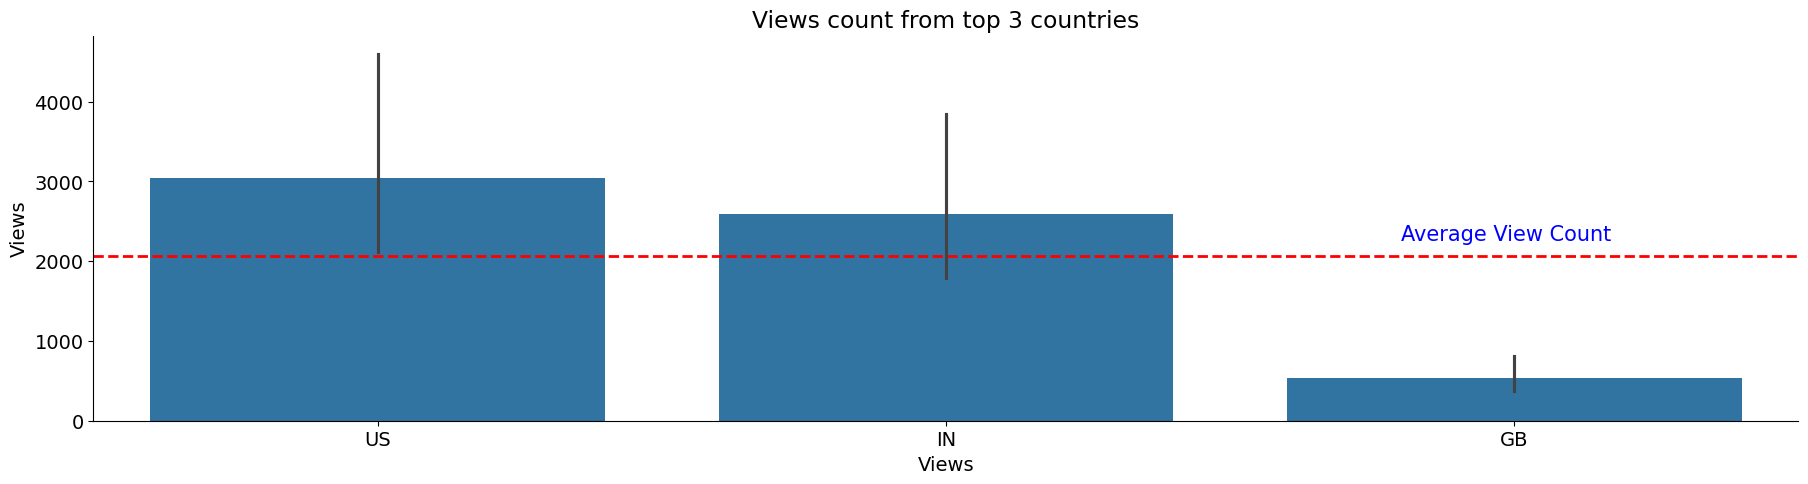

In [40]:
df = Country_df[['Video Title', 'Views', 'Average Watch Time', 'Country Code']].copy().sort_values(by='Views',ascending= False)
US_df = df[df['Country Code']=='US']
IN_df = df[df['Country Code']=='IN']
GB_df = df[df['Country Code']=='GB']
audience = pd.concat([US_df, IN_df, GB_df], axis=0, sort=False).sort_values(by='Views',ascending= False)

sns.barplot(x=audience['Country Code'] , y= audience['Views'])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axhline(audience['Views'].mean(), linestyle='--', lw=2, zorder=1, color='red')
plt.annotate(f'Average View Count', (1.8, audience['Views'].mean()+200), fontsize=15, color='blue')

plt.title("Views count from top 3 countries")
plt.xlabel('Views')
plt.show()

In [41]:
audience.groupby('Video Title').sum().sort_values(by='Views',ascending= False).head(5).index.tolist()

['How I Would Learn Data Science (If I Had to Start Over)',
 'The Best Free Data Science Courses Nobody is Talking About',
 '3 Proven Data Science Projects for Beginners (Kaggle)',
 'Beginner Kaggle Data Science Project Walk-Through (Titanic)',
 'The Projects You Should Do To Get A Data Science Job']


<b>INTERPRETATION: </b> The people from US, India and Great Britain watch these top 5 videos the most



</div>
  </center>

- 'How I Would Learn Data Science (If I Had to Start Over)',
- 'The Best Free Data Science Courses Nobody is Talking About',
- '3 Proven Data Science Projects for Beginners (Kaggle)',
- 'Beginner Kaggle Data Science Project Walk-Through (Titanic)',
- 'Data Science Certificate vs Bootcamp vs Masters Degree']

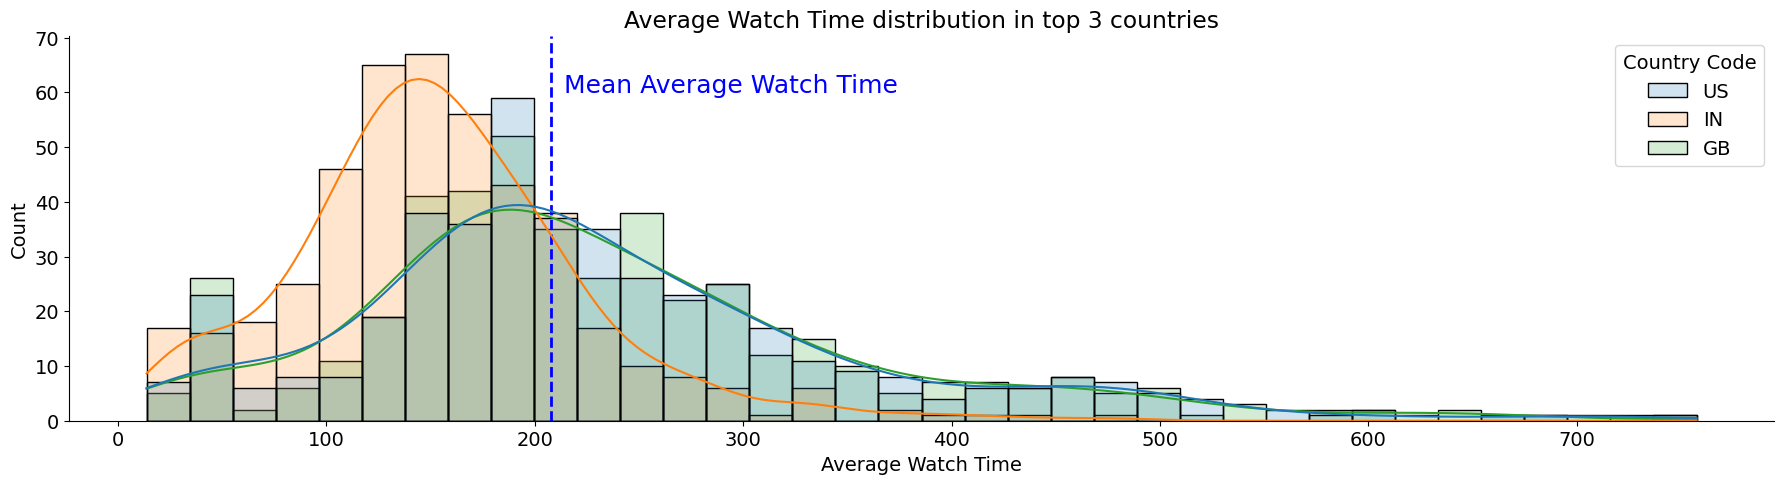

In [42]:
sns.histplot(data=audience, x=audience['Average Watch Time'], hue='Country Code', kde=True, alpha=0.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(audience['Average Watch Time'].mean(), linestyle='--', lw=2, zorder=1, color='blue')
plt.annotate(f' Mean Average Watch Time', (210, 60), fontsize=18,color='blue')
plt.title('Average Watch Time distribution in top 3 countries')
plt.show()

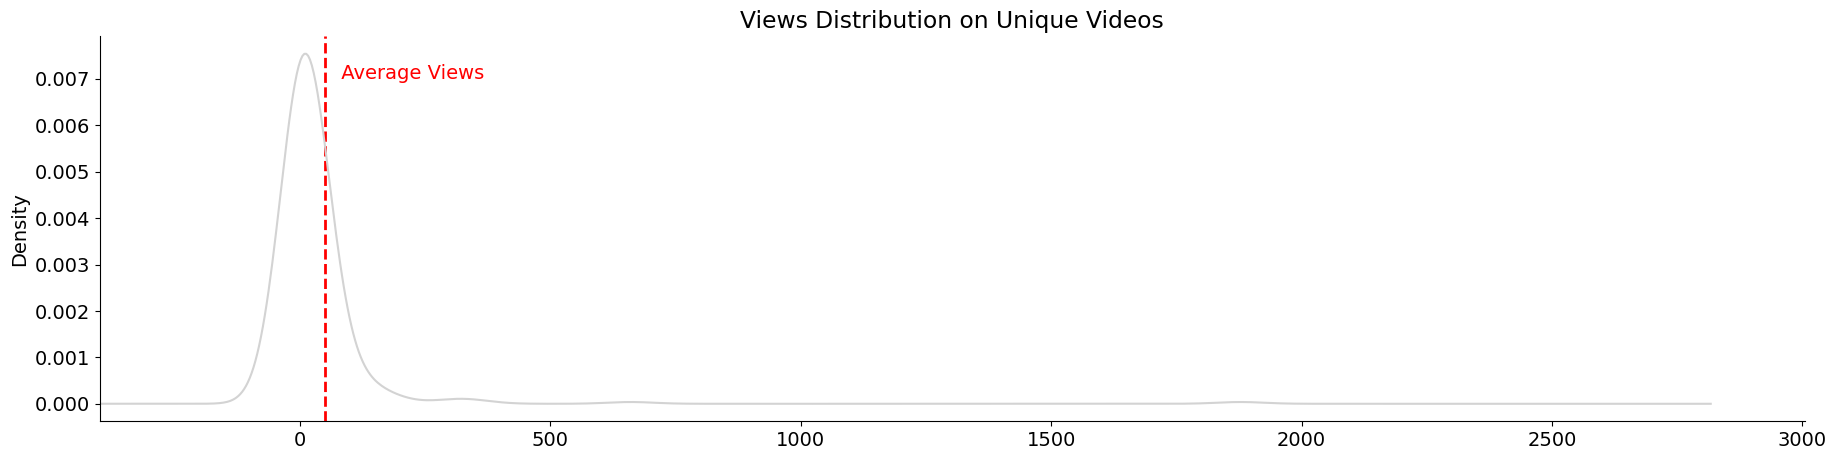

In [43]:
Video_df.drop_duplicates('Video Title')['Views'].plot(kind='kde', color='lightgray')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(Video_df['Views'].mean(), linestyle='--', lw=2, zorder=0, color='red')
plt.annotate(f' Average Views', (Video_df['Views'].mean()+20, 0.007),color='red')
plt.title('Views Distribution on Unique Videos')
plt.xlim(left = -400)
plt.show()

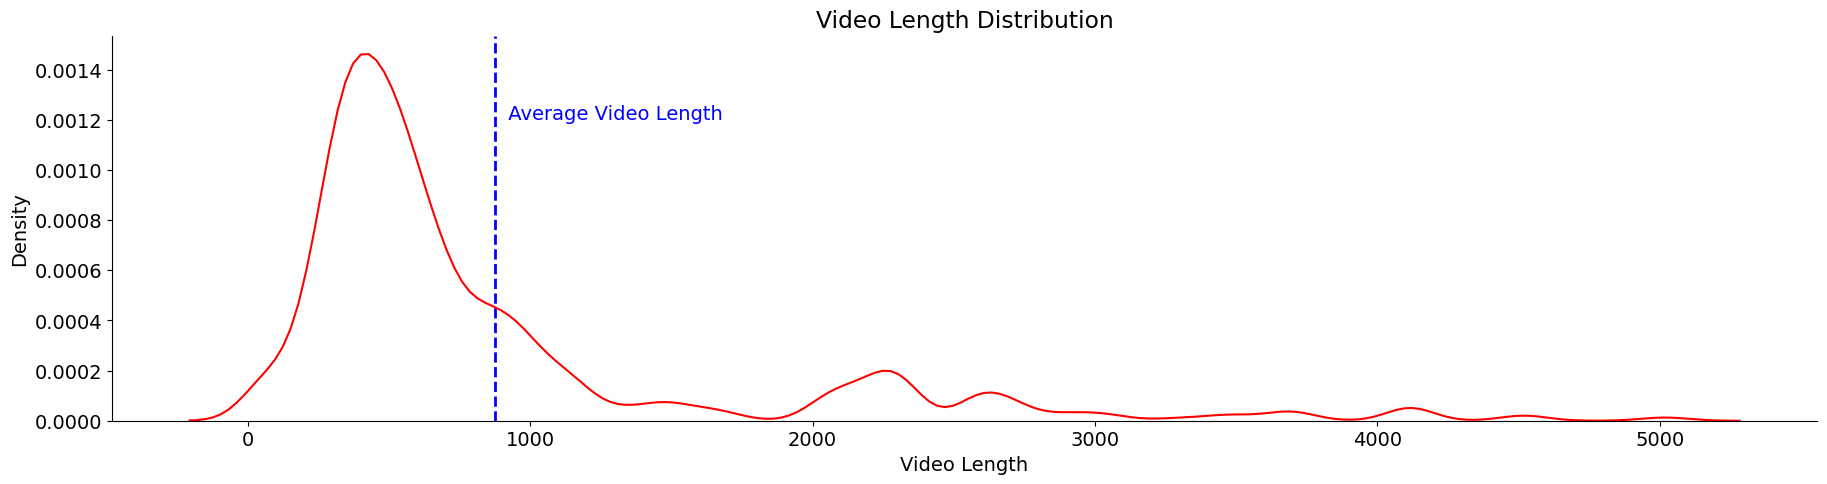

In [44]:
ax= sns.kdeplot(data=Video_df, x=Video_df['Video Length'], color='lightgray', alpha=0.2)
ax.lines[0].set_color('red')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(Video_df['Video Length'].mean(), linestyle='--', lw=2, zorder=1, color='blue')
plt.annotate(f' Average Video Length', (900, 0.0012),color='blue')
plt.title('Video Length Distribution')
plt.show()

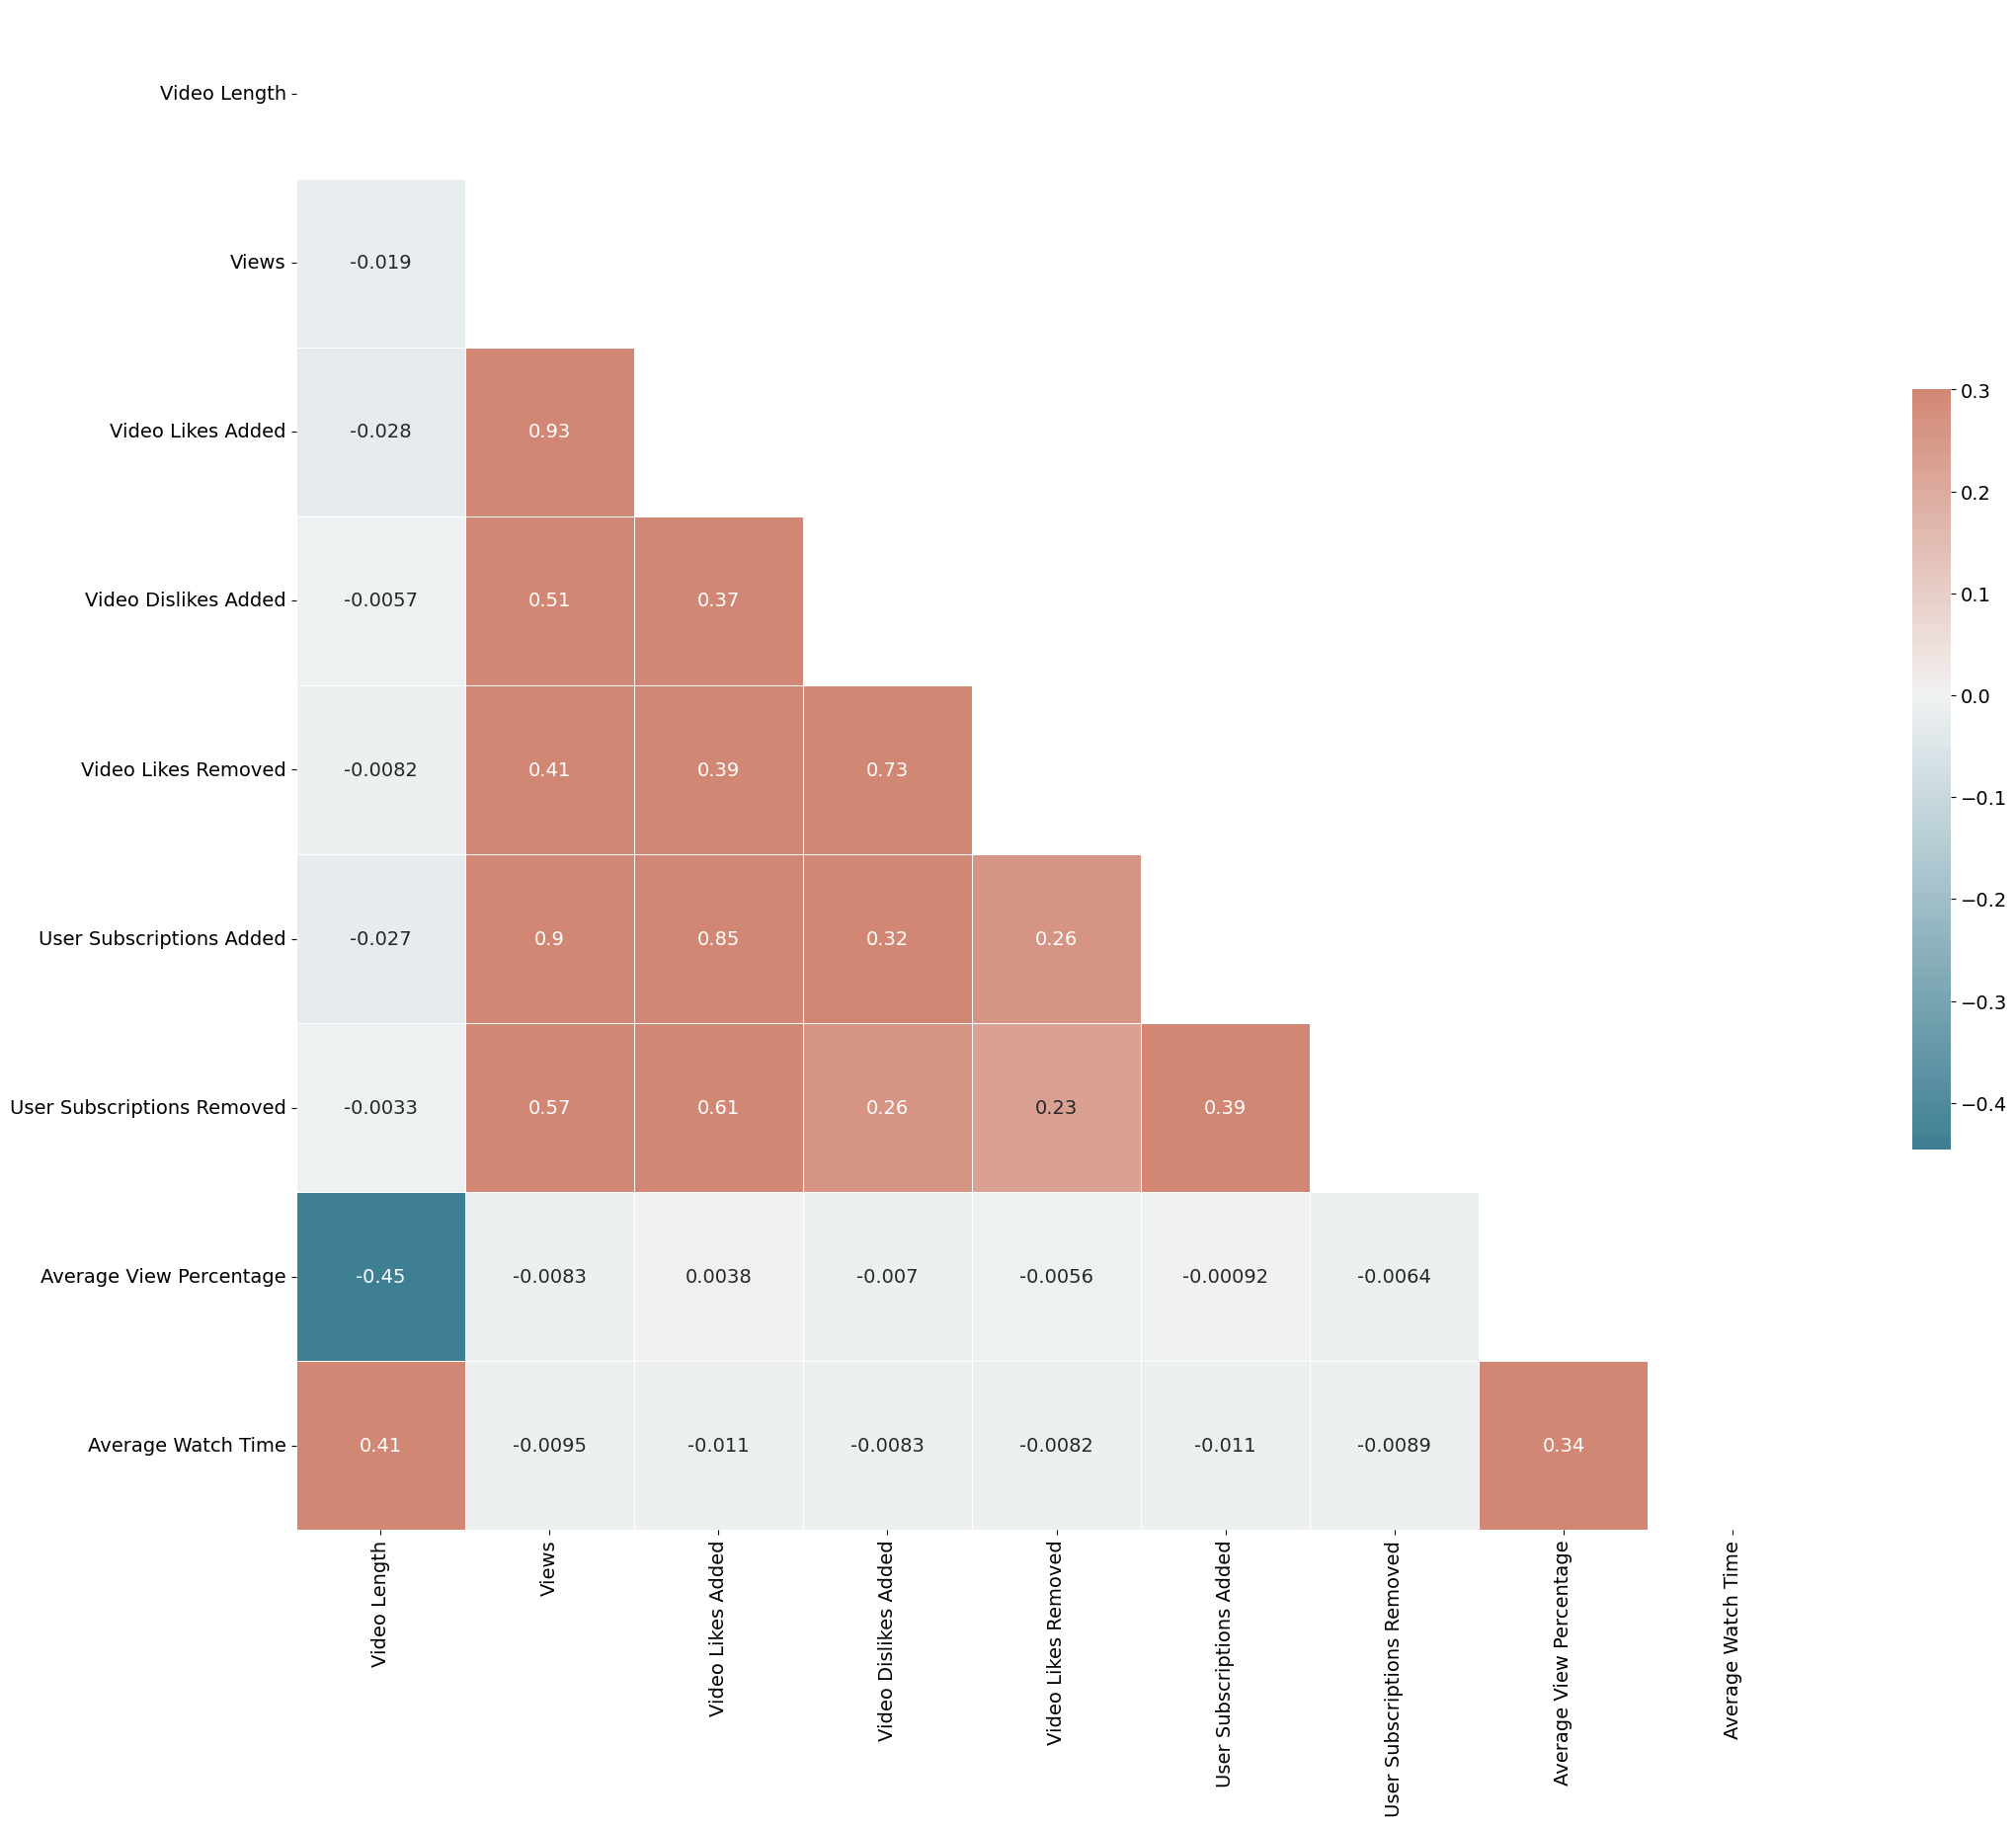

In [45]:
corr = Video_df[['Video Length', 'Views', 'Video Likes Added', 'Video Dislikes Added', 'Video Likes Removed',
        'User Subscriptions Added','User Subscriptions Removed', 'Average View Percentage','Average Watch Time']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(25,20))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,square=True, linewidths=.5, cbar_kws={'shrink': .5})
plt.show()

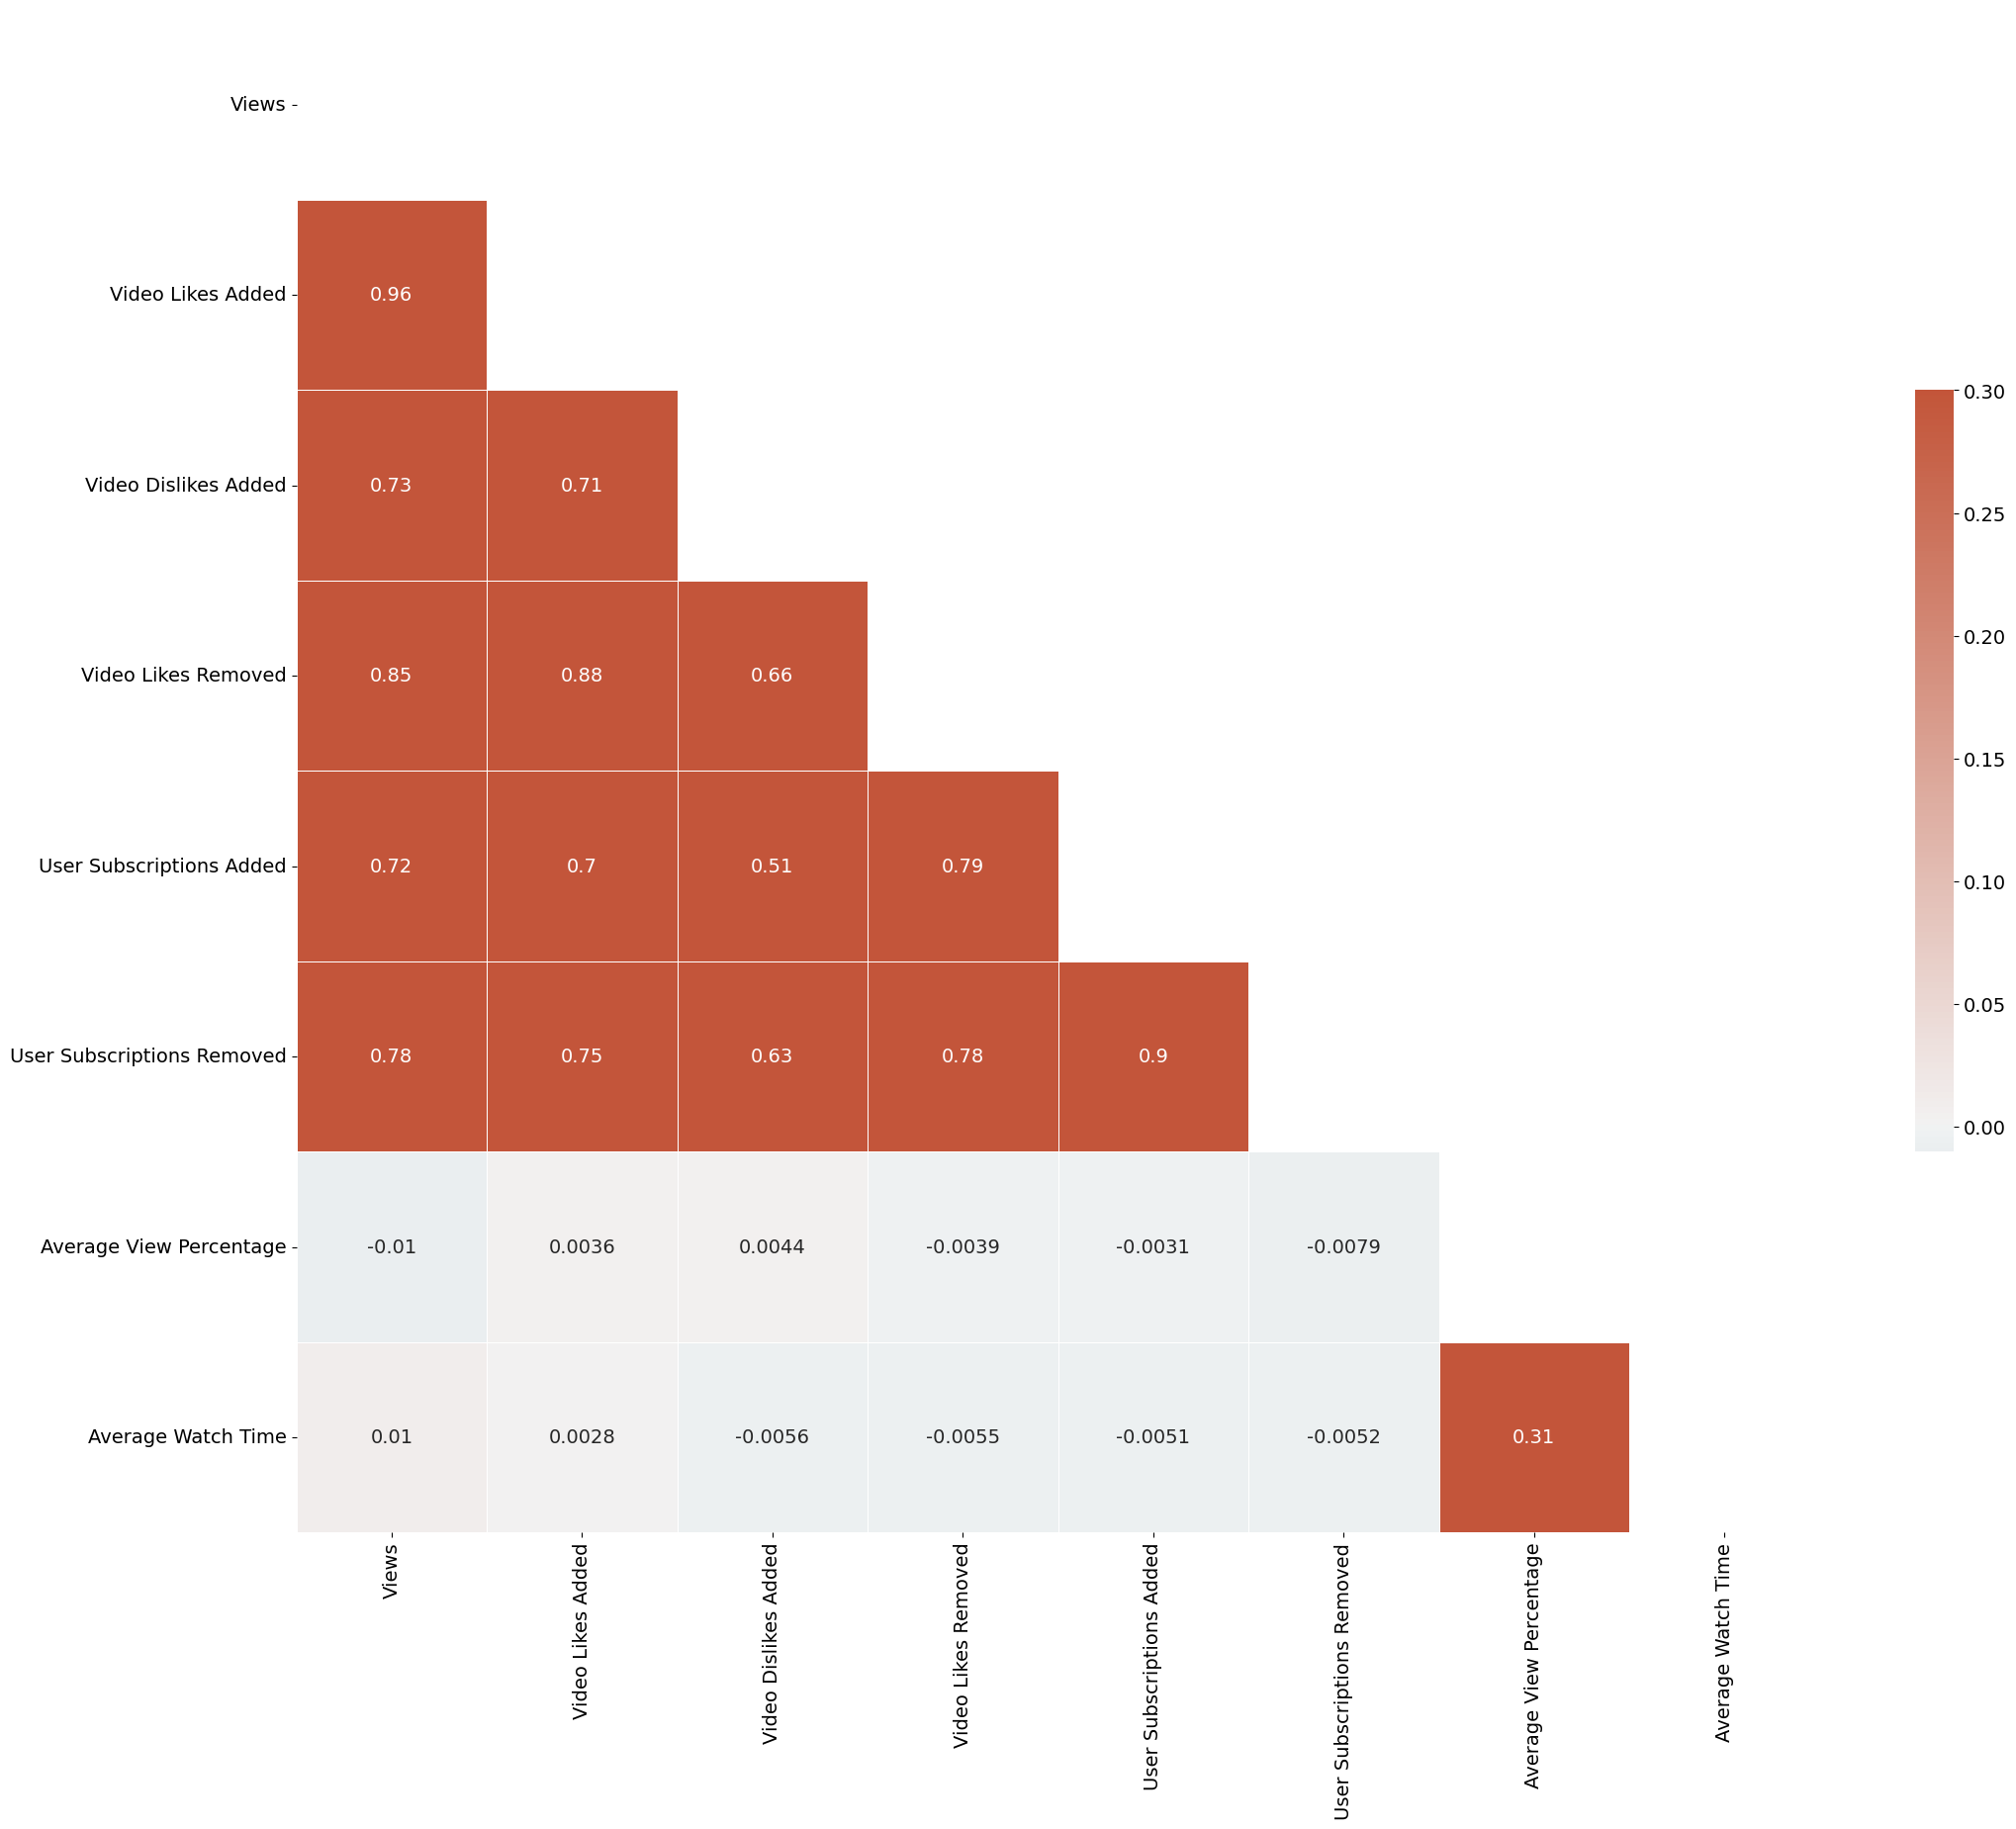

In [46]:
corr = True_df[['Views', 'Video Likes Added',
       'Video Dislikes Added', 'Video Likes Removed',
       'User Subscriptions Added', 'User Subscriptions Removed',
       'Average View Percentage', 'Average Watch Time']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(25,20))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,square=True, linewidths=.5, cbar_kws={'shrink': .5})
plt.show()

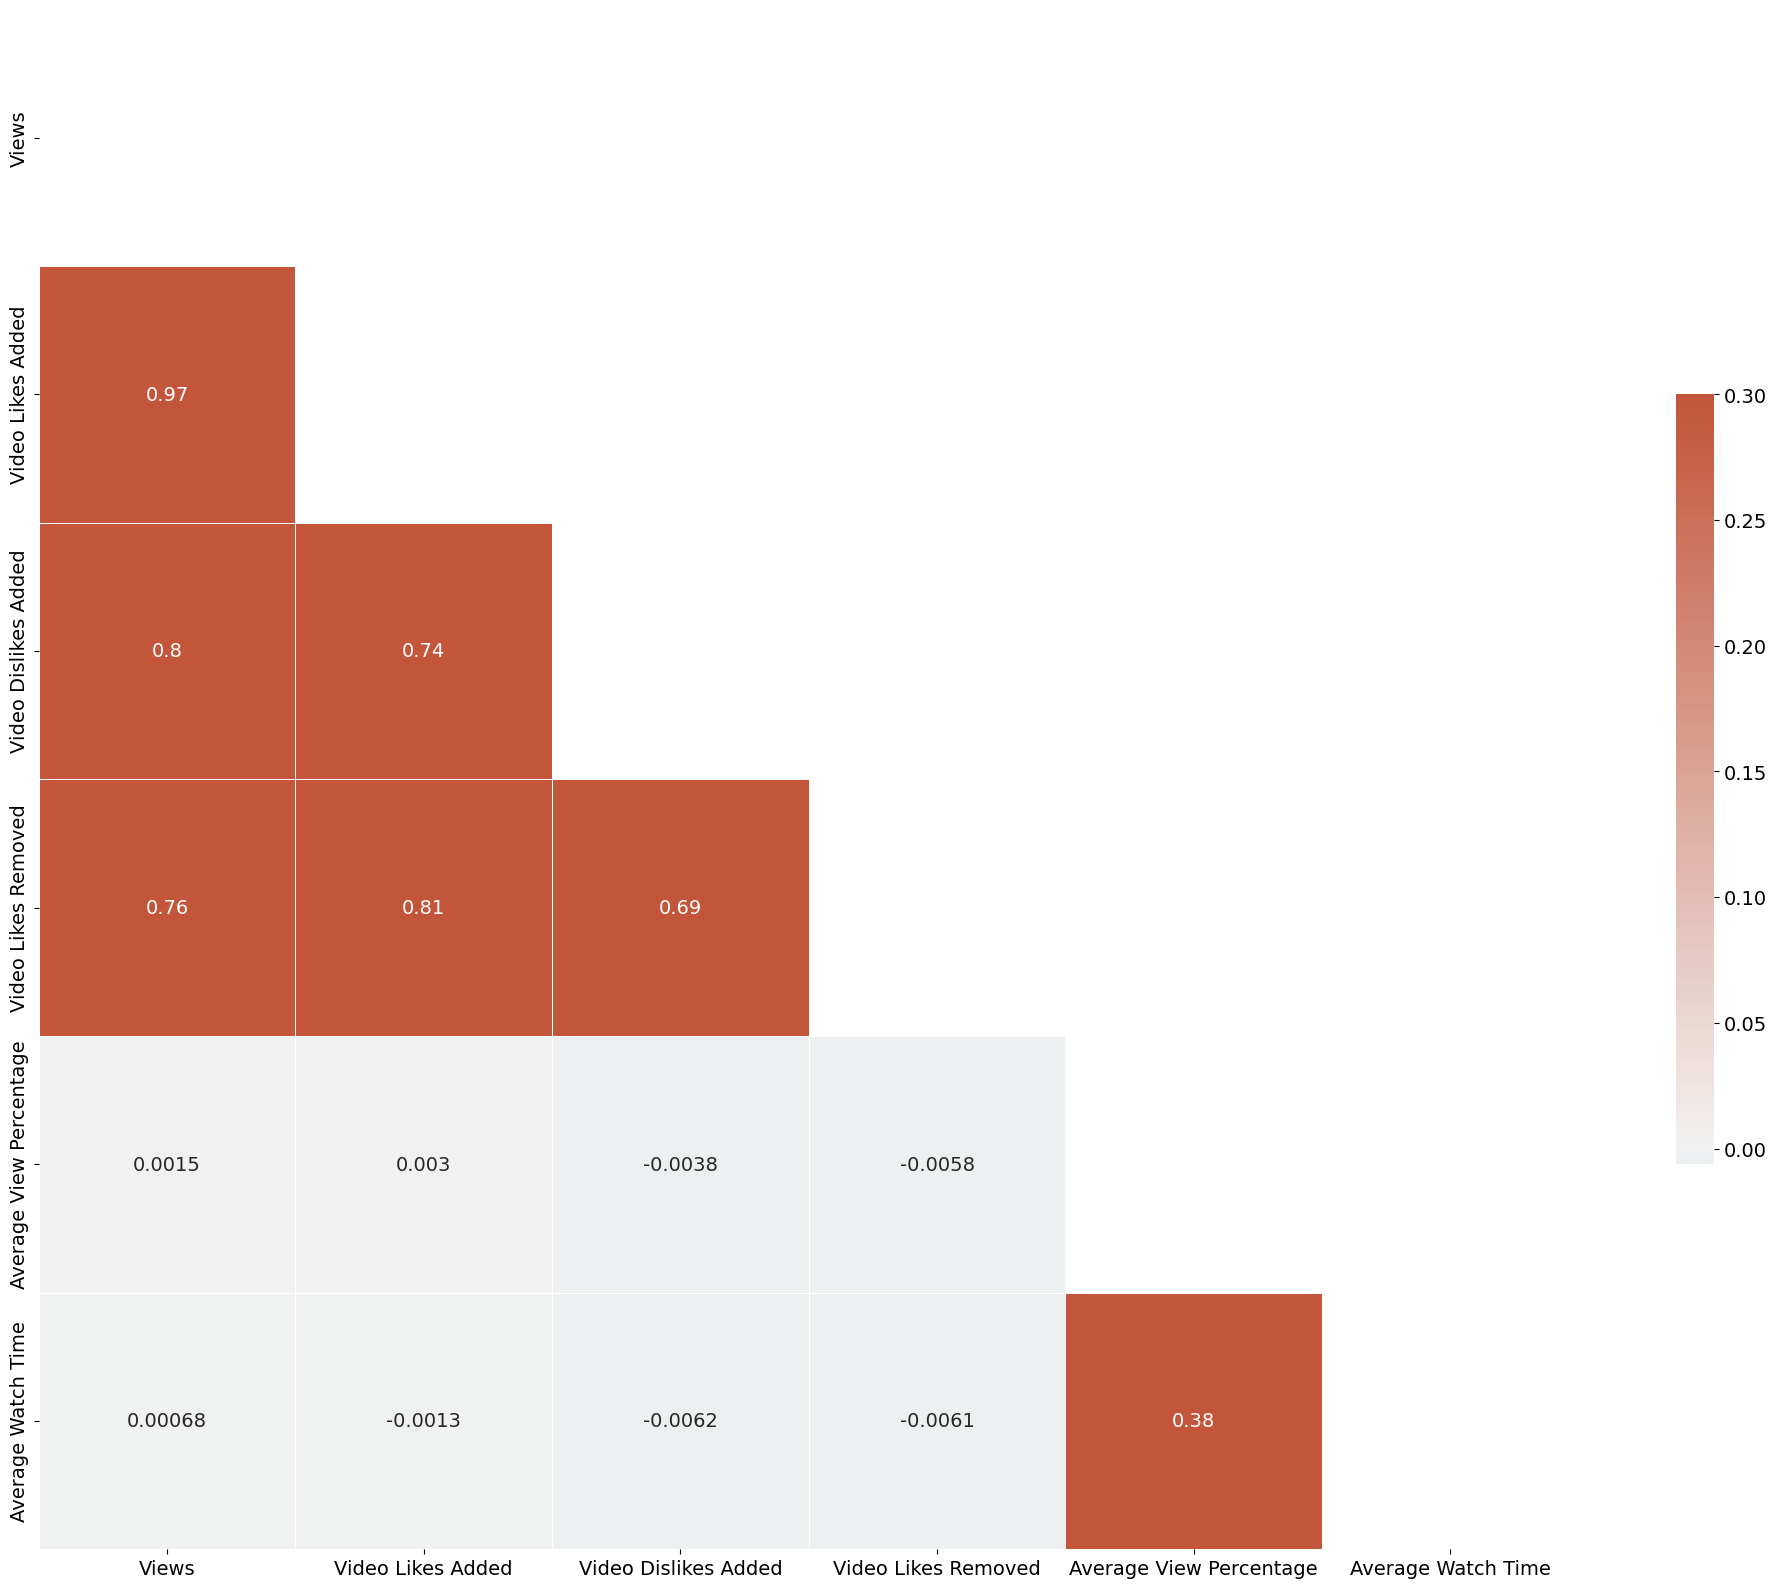

In [47]:
corr = False_df[['Views', 'Video Likes Added',
       'Video Dislikes Added', 'Video Likes Removed',
       'Average View Percentage', 'Average Watch Time']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(25,20))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True,square=True, linewidths=.5, cbar_kws={'shrink': .5})
plt.show()

<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Q: What type of content are people engaging with the most or watching the longest?
    
</h2>
</div>
    
</center>

In [48]:
#Top videos that have garnered the most views
Views_df = Video_df[['Video Title','External Video ID', 'Views']].copy().sort_values(by='Views',ascending= False)
Views_df.drop_duplicates('Video Title',inplace=True)
Views_df['Video Title'].head(10).values.tolist()

['How I Would Learn Data Science (If I Had to Start Over)',
 'How I Learned Data Science',
 'Reviewing Your Data Science Projects - Episode 5 (Very Detailed Project)',
 'Different Data Science Roles Explained (by a Data Scientist)',
 'Why I Quit Data Science',
 'The State of Data Science with Krish Naik & The Data Professor [Panel Discussion]',
 'How I Would Learn Data Science in 2022 (If I Had to Start Over)',
 "Why You Probably Won't Become a Data Scientist",
 'Is Data Science Right For You?',
 'Reviewing Your Data Science Projects - Episode 4 (Resume & Github)']



<center>
<div class="alert alert-block alert-info">
 From the results, evidently people are keen to know about



</div>
  </center>


- Data Science Roadmap
- Projects
- Roles in Datascience

In [49]:
Video_df.groupby('Video Title').sum().sort_values(by='Average Watch Time',ascending= False).head(5).index.tolist()

['Uber Driver to Machine Learning Engineer in 9 Months! (@Daniel Bourke) - KNN EP. 05',
 'Data Science Project from Scratch - Part 4 (Exploratory Data Analysis)',
 'Data Science Fundamentals: Data Manipulation in Python (Pandas)',
 'Data Science Project from Scratch - Part 3 (Data Cleaning)',
 'Advice from a Data Analytics CEO (@How to Get an Analytics Job) - KNN EP. 17']



<center>
<div class="alert alert-block alert-info">
Top 5 videos that have been watched the longest are:-




</div>
  </center>

- 'Uber Driver to Machine Learning Engineer in 9 Months! (@Daniel Bourke) - KNN EP. 05',
- 'Data Science Project from Scratch - Part 4 (Exploratory Data Analysis)',
- 'Data Science Fundamentals: Data Manipulation in Python (Pandas)',
- 'Data Science Project from Scratch - Part 3 (Data Cleaning)',
- 'Advice from a Data Analytics CEO (@How to Get an Analytics Job) - KNN EP. 17'

<center>
<div style="color:;
           displaya:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Q. What are the themes of the comment data?
    
</h2>
</div>
    
</center>

In this section we will be doing Sentiment analysis of the comments and most commented video too.
<a id = Section4></a>

<center>
<div style="color:;
           displaya:fill;
           border-radius:5px;
           background-color: lightgray;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:black;">Sentiment analysis
    
</h2>
</div>
    
</center>


**Sentiment analysis**, also known as opinion mining, is a natural language processing (NLP) task that involves determining the sentiment or emotion expressed in a piece of text. The main goal of sentiment analysis is to understand whether the expressed opinion is positive, negative, neutral, or sometimes more granular emotions like happy, sad, angry, etc. This has numerous applications in various fields, such as market research, social media monitoring, customer feedback analysis, and more.

*Traditional sentiment analysis* approaches often relied on hand-crafted features and machine learning algorithms like Support Vector Machines (SVM), Naive Bayes, or logistic regression. These models required domain-specific feature engineering and lacked the ability to capture complex language patterns effectively.

In [50]:
print('Comments on videos - ', format(len(Comments_df['comments'])))
print('Unique Videos - ', format(Comments_df['vidid'].nunique()))
print('Comments per Video -', format(int(len(Comments_df['comments'])/Comments_df['vidid'].nunique())))

Comments on videos -  10240
Unique Videos -  222
Comments per Video - 46


In [51]:
Comments_df.head()

,comments,comment_id,reply_count,like_count,date,vidid,user_id,clean comments,polarity,sentiment
0,Thanks for this video Ken.\n\nI decided to go ...,UgxFZTIzC4UPyhhX_PZ4AaABAg,0,0,2022-01-22T08:13:29Z,xpIFS6jZbe8,user_981,thanks for this video keni decided to go into ...,0.130,Positive
1,Hello ken jee!!! I'm doing a graduation on Com...,Ugx3IYuAufhb932GYQx4AaABAg,0,0,2022-01-22T01:09:46Z,xpIFS6jZbe8,user_213,hello ken jee im doing a graduation on compute...,0.433,Positive
2,"Thanks for this video, man. So useful. I'll me...",UgyhwwoK24arzRt1mud4AaABAg,0,0,2022-01-21T23:59:05Z,rEWPqw6rMGI,user_1065,thanks for this video man so useful ill meet y...,0.000,Neutral
3,Great video!!! I started learning Python 8 mon...,UgwrrI7nd3WClsotmHV4AaABAg,0,0,2022-01-21T23:00:37Z,xpIFS6jZbe8,user_3391,great video i started learning python 8 months...,0.417,Positive
4,Been watching hours of your material (and Tina...,UgxlOrHO4MHKSwY9mUN4AaABAg,0,0,2022-01-21T20:24:20Z,sHRq-LshG3U,user_2816,been watching hours of your material and tina ...,0.342,Positive


In [52]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return "" # Handle non-string inputs by returning an empty string
    # Convert text to lowercase
    text = text.lower().strip()
    # Remove common punctuation marks and special characters using regex
    text = re.sub(r"([-?.!,/\"])", '', text)
    text = re.sub(r"[-()\"#/@;:<>{}`+=~|.!?,']", "", text)
    # Replace multiple spaces with a single space
    text = re.sub(r"[ ]+", " ", text)
    # Remove double newlines
    text = re.sub('\n\n','', text)
    # Strip leading/trailing whitespace again
    text = text.rstrip().strip()
    return text

In [53]:
clean_text(Comments_df['comments'][0])

'thanks for this video keni decided to go into tech in 2018 by learning web development learnt a bit of html css and javascript my goals has since evolved through this period as i got interested in python programming and data sciencemy current interest now tends towards deep learning and aiinteresting my knowledge of front end web development will be very helpful in web scraping'

In [54]:
clean_comments = []
for i in range(len(Comments_df['comments'])):
    # The clean_text function is now more robust and handles non-string inputs
    clean_comments.append(clean_text(Comments_df['comments'][i]))
    if i % 1000==0:
        print(f'{i} iteration(s) completed')
Comments_df['Clean Comments'] = clean_comments

0 iteration(s) completed
1000 iteration(s) completed
2000 iteration(s) completed
3000 iteration(s) completed
4000 iteration(s) completed
5000 iteration(s) completed
6000 iteration(s) completed
7000 iteration(s) completed
8000 iteration(s) completed
9000 iteration(s) completed
10000 iteration(s) completed


- **Polarity** is a float value within the range **[-1.0 to 1.0]**.
  
  - Here, **0** indicates **neutral**,
  
  - **+1** indicates a **very positive** sentiment, and
  
  - **-1** represents a **very negative** sentiment.


In [55]:
from textblob import TextBlob

# Calculate polarity first
polarity = []
for i in Comments_df['Clean Comments']:
    blob = TextBlob(i)
    polarity.append(round(blob.sentiment.polarity,3))
Comments_df['polarity'] = polarity
print('Polarity Column added to the dataframe')

# Now, ensure 'sentiment' column exists before mapping
sentiment = []
for i in range(len(Comments_df['polarity'])):
    if Comments_df['polarity'][i] > 0:
        sentiment.append('Positive')
    elif Comments_df['polarity'][i] < 0:
        sentiment.append('Negative')
    else:
        sentiment.append('Neutral')
Comments_df['sentiment'] = sentiment
print('Sentiment column has been added to the dataframe.')

Polarity Column added to the dataframe
Sentiment column has been added to the dataframe.


In [56]:
print('Reviews with Positive Sentiment based on Polarity :', len(Comments_df[Comments_df['polarity'] > 0]))
print('Reviews with Negative Sentiment based on Polarity :', len(Comments_df[Comments_df['polarity'] < 0]))
print('Reviews with Neutral Sentiment based on Polarity :', len(Comments_df[Comments_df['polarity'] == 0]))

Reviews with Positive Sentiment based on Polarity : 7117
Reviews with Negative Sentiment based on Polarity : 801
Reviews with Neutral Sentiment based on Polarity : 2322


In [57]:
Comments_df.head()

,comments,comment_id,reply_count,like_count,date,vidid,user_id,clean comments,polarity,sentiment,Clean Comments
0,Thanks for this video Ken.\n\nI decided to go ...,UgxFZTIzC4UPyhhX_PZ4AaABAg,0,0,2022-01-22T08:13:29Z,xpIFS6jZbe8,user_981,thanks for this video keni decided to go into ...,0.130,Positive,thanks for this video keni decided to go into ...
1,Hello ken jee!!! I'm doing a graduation on Com...,Ugx3IYuAufhb932GYQx4AaABAg,0,0,2022-01-22T01:09:46Z,xpIFS6jZbe8,user_213,hello ken jee im doing a graduation on compute...,0.433,Positive,hello ken jee im doing a graduation on compute...
2,"Thanks for this video, man. So useful. I'll me...",UgyhwwoK24arzRt1mud4AaABAg,0,0,2022-01-21T23:59:05Z,rEWPqw6rMGI,user_1065,thanks for this video man so useful ill meet y...,0.000,Neutral,thanks for this video man so useful ill meet y...
3,Great video!!! I started learning Python 8 mon...,UgwrrI7nd3WClsotmHV4AaABAg,0,0,2022-01-21T23:00:37Z,xpIFS6jZbe8,user_3391,great video i started learning python 8 months...,0.417,Positive,great video i started learning python 8 months...
4,Been watching hours of your material (and Tina...,UgxlOrHO4MHKSwY9mUN4AaABAg,0,0,2022-01-21T20:24:20Z,sHRq-LshG3U,user_2816,been watching hours of your material and tina ...,0.342,Positive,been watching hours of your material and tina ...


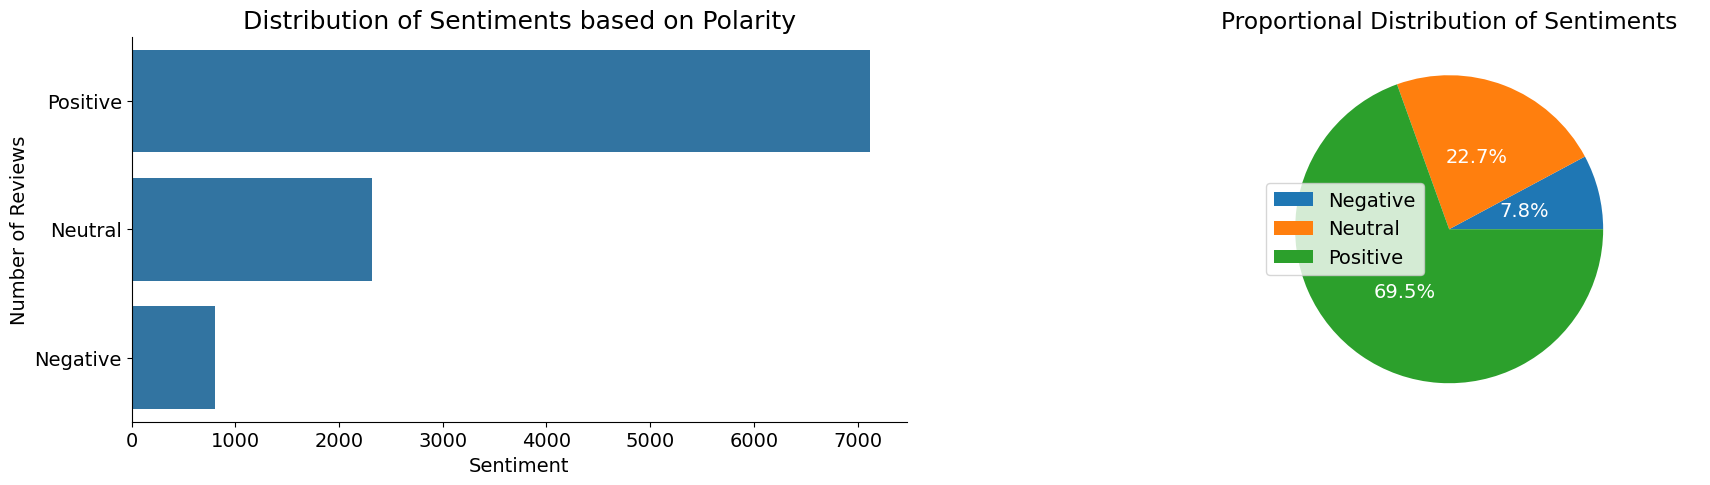

In [58]:
# Plotting the Count and Proportional Distribution of reviews based on sentiment as per polarity
plt.subplot(1, 2, 1)

# Plotting the count of reviews for each sentiment
sns.countplot(Comments_df['sentiment'],  )
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Sentiments based on Polarity', fontsize=18)

plt.subplot(1, 2, 2)
# Plotting the proportional distribution of sentiments
plt.pie(x=[len(Comments_df[Comments_df['polarity'] < 0]), len(Comments_df[Comments_df['polarity'] == 0]),
           len(Comments_df[Comments_df['polarity'] > 0])],
        labels=['Negative', 'Neutral', 'Positive'], autopct='%1.1f%%', pctdistance=0.5,
        textprops={'fontsize':14, 'color':'white'})
plt.title('Proportional Distribution of Sentiments')
plt.legend()
plt.show()

In [59]:
#Making a new dataframe for further use
df=Comments_df[['vidid','polarity','sentiment' ]].copy()

<a id = Section4.1></a>

<center>
<div style="color:;
           displaya:fill;
           border-radius:5px;
           background-color: lightblue;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 10px;
              color:black;">Sentiment analysis Using BERT
    
</h3>
</div>

BERT (*Bidirectional Encoder Representations from Transformers*) is a deep learning model introduced by Google in 2018, which significantly advanced the field of NLP. Unlike traditional models that process text in a sequential manner, BERT utilizes a transformer-based architecture, enabling it to capture the context of words bidirectionally (both left and right) in a sentence.

Here's a brief overview of BERT's architecture and its key components:

1. **Transformer Encoder**: The transformer architecture relies on self-attention mechanisms, allowing it to weigh the importance of different words in the context of the whole sentence. This attention mechanism is used to generate contextualized word embeddings for each word in the sentence.

2. **Pre-training**: BERT is pre-trained on a large corpus of text using a masked language model objective. During pre-training, some words in the input are randomly masked, and the model is trained to predict the masked words based on the surrounding context. This process helps BERT learn rich contextual representations of words.

3. **Fine-tuning**: After pre-training, BERT is fine-tuned on specific downstream tasks like sentiment analysis. During fine-tuning, the model's weights are adjusted to adapt it to the target task.

Now, let's discuss how BERT makes sentiment analysis more effective and easier:

1. **Contextual Word Representations**: BERT's bidirectional nature enables it to understand the context in which a word appears in a sentence. This contextual understanding allows BERT to capture nuances in sentiment, such as sarcasm or negation, which were challenging for traditional methods to handle.

2. **Transfer Learning**: BERT is pre-trained on a large amount of general text data. This pre-training captures a wide range of language patterns and features, making it highly effective for a wide array of NLP tasks, including sentiment analysis. Fine-tuning on task-specific data further refines the model's performance.

3. **No Need for Hand-Crafted Features**: BERT does not require extensive hand-crafted feature engineering. It automatically learns and represents features from the data during pre-training and fine-tuning.

4. **State-of-the-art Performance**: BERT has achieved state-of-the-art performance on various NLP benchmarks, including sentiment analysis tasks, surpassing the performance of many traditional models.

So, BERT's bidirectional contextual word representations and transfer learning capabilities have revolutionized the field of sentiment analysis. By capturing the rich context and semantics of language, BERT offers superior performance and simplifies the process of sentiment analysis, making it a breeze compared to traditional approaches.

In [60]:
#Downloading the model and the tokenizer
tokenizer = AutoTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

model = AutoModelForSequenceClassification.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [61]:
tokens = tokenizer.encode(Comments_df['comments'][0], return_tensors='pt')
result = model(tokens)
print(f'The sentiment of the first comment is {int(torch.argmax(result.logits))+1}')

The sentiment of the first comment is 5


In [62]:
def sentiment_score(review):
    tokens = tokenizer.encode(review, return_tensors='pt')
    result = model(tokens)
    return int(torch.argmax(result.logits))+1

In [63]:
for i in range(0,10):
    score = sentiment_score(Comments_df['comments'][i])
    comment = Comments_df['comments'][i]
    print(f'Comment : {comment[0:100]}, Score : {score}.')
    print('\n')

Comment : Thanks for this video Ken.

I decided to go into Tech in 2018 by learning web development. Learnt a , Score : 5.


Comment : Hello ken jee!!! I'm doing a graduation on Computer Science and i really keen to learn Data Science., Score : 5.


Comment : Thanks for this video, man. So useful. I'll meet you when I'm a Senior Lead Data Scientist at the Co, Score : 5.


Comment : Great video!!! I started learning Python 8 months ago and quickly became interested in DS, I have a , Score : 5.


Comment : Been watching hours of your material (and Tina) because while I do know that it is not an easy field, Score : 5.


Comment : Hey Ken! I am almost finishing my university degreed in market research & marketing and I am going t, Score : 2.


Comment : So basically is it modest to say that the silver bullet to get into a good role is:
➡️to have had So, Score : 3.


Comment : Hi Ken, as always, your videos are insightful and easy to follow. Would you say that  one of the mai, Score : 4.




We can see how easy it is to get the sentiment analysis with the BERT model. This allows us to spend more time on analysis rather than figuring out how to build the pipeline here. I have not ran the algo on the whole comments because of the limited computational power here on Kaggle

In [64]:
example_comment = "This video is absolutely fantastic!"

tokens = tokenizer.encode(example_comment, return_tensors='pt')

model_output = model(tokens)

# Extract the logits
logits = model_output.logits

# Get the predicted class by finding the index of the max logit
# Add 1 because the model outputs scores 0-4 for sentiments 1-5
predicted_sentiment_score = int(torch.argmax(logits)) + 1

print(f"Example Comment: '{example_comment}'")
print(f"Predicted Sentiment Score (1-5): {predicted_sentiment_score}")

example_comment_negative = "This was a really bad explanation, very unhelpful."
tokens_negative = tokenizer.encode(example_comment_negative, return_tensors='pt')
model_output_negative = model(tokens_negative)
logits_negative = model_output_negative.logits
predicted_sentiment_score_negative = int(torch.argmax(logits_negative)) + 1

print(f"\nExample Comment: '{example_comment_negative}'")
print(f"Predicted Sentiment Score (1-5): {predicted_sentiment_score_negative}")

Example Comment: 'This video is absolutely fantastic!'
Predicted Sentiment Score (1-5): 5

Example Comment: 'This was a really bad explanation, very unhelpful.'
Predicted Sentiment Score (1-5): 1


In [65]:
display(Comments_df.head())

,comments,comment_id,reply_count,like_count,date,vidid,user_id,clean comments,polarity,sentiment,Clean Comments
0,Thanks for this video Ken.\n\nI decided to go ...,UgxFZTIzC4UPyhhX_PZ4AaABAg,0,0,2022-01-22T08:13:29Z,xpIFS6jZbe8,user_981,thanks for this video keni decided to go into ...,0.130,Positive,thanks for this video keni decided to go into ...
1,Hello ken jee!!! I'm doing a graduation on Com...,Ugx3IYuAufhb932GYQx4AaABAg,0,0,2022-01-22T01:09:46Z,xpIFS6jZbe8,user_213,hello ken jee im doing a graduation on compute...,0.433,Positive,hello ken jee im doing a graduation on compute...
2,"Thanks for this video, man. So useful. I'll me...",UgyhwwoK24arzRt1mud4AaABAg,0,0,2022-01-21T23:59:05Z,rEWPqw6rMGI,user_1065,thanks for this video man so useful ill meet y...,0.000,Neutral,thanks for this video man so useful ill meet y...
3,Great video!!! I started learning Python 8 mon...,UgwrrI7nd3WClsotmHV4AaABAg,0,0,2022-01-21T23:00:37Z,xpIFS6jZbe8,user_3391,great video i started learning python 8 months...,0.417,Positive,great video i started learning python 8 months...
4,Been watching hours of your material (and Tina...,UgxlOrHO4MHKSwY9mUN4AaABAg,0,0,2022-01-21T20:24:20Z,sHRq-LshG3U,user_2816,been watching hours of your material and tina ...,0.342,Positive,been watching hours of your material and tina ...


<center>
<div style="color:;
           displaya:fill;
           border-radius:5px;
           background-color: lightgray;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 10px;
              color:black;">Top Vids (with highest positive polarity)
    
</h3>
</div>
    
</center>

In [66]:
df.sort_values(by='polarity',ascending= False).head(5)

,vidid,polarity,sentiment
8993,1aXk2RViq3c,1.0,Positive
4882,domVw8isGOI,1.0,Positive
6560,YbTMIxjk4hI,1.0,Positive
6402,iGUiLWFDWfk,1.0,Positive
2445,hOUrxTeBJQc,1.0,Positive


<center>
<div style="color:;
           displaya:fill;
           border-radius:5px;
           background-color: lightgray;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 10px;
              color:black;">Bottom Vids (with highest negative polarity)
    
</h3>
</div>
    
</center>

In [67]:
df.sort_values(by='polarity',ascending= False).tail(5)

,vidid,polarity,sentiment
1785,sHRq-LshG3U,-0.875,Negative
7176,_rbrdNTpZGo,-0.910,Negative
9956,T77uVbLhroQ,-0.910,Negative
6726,4OZip0cgOho,-1.000,Negative
29,Q9FjwzKFPuM,-1.000,Negative


<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 10px;
              color:white;">Words Used In Positive Comments
    
</h3>
</div>
    
</center>

We will be using something known as Word Cloud to visualize the words.

What is Word Cloud you ask? Well, A **word cloud** is a visual representation of text data where the most frequently occurring words in a given piece of text are displayed in a graphical form. In a word cloud, the size of each word is proportional to its frequency in the text. The more frequently a word appears in the text, the larger and bolder it appears in the word cloud.

Word clouds are often used to **provide a quick and intuitive overview** of the most important or commonly used words in a document, a collection of documents, or any other textual data source. They are particularly useful for identifying key themes, topics, or sentiments present in the text.

Creating a word cloud typically involves the following steps:

1. **Text Processing**: The text data is preprocessed to remove common stop words (e.g., "the," "is," "and," etc.) and other irrelevant or noisy words. The remaining words are then used to build the word cloud.

2. **Word Frequency Count**: The frequency of each word is calculated to determine how often it appears in the text.

3. **Word Cloud Visualization**: The words and their respective frequencies are represented graphically in the form of a word cloud. The more frequent a word, the larger and more prominent it appears in the cloud.

Word clouds are often used for various purposes, such as:

- Visualizing the content of a document or an article.
- Understanding the most common topics discussed in customer reviews, feedback, or social media comments.
- Analyzing responses in surveys to identify prevalent keywords or themes.
- Gaining insights into the vocabulary used in a specific domain or text corpus.
- Creating visually appealing artwork or illustrations based on text data.

Word clouds are easy to interpret and provide a quick overview of the most relevant information in a visually engaging manner. However, it's important to note that word clouds have limitations, particularly when dealing with large volumes of text. They may not capture the full context of the text or convey more intricate relationships between words. In some cases, more advanced text analysis techniques, such as topic modeling or sentiment analysis, may be required for deeper insights into the textual data.

In [68]:
wordcloud = WordCloud(width=2500, height=2000, max_words=50,
                      background_color='White').generate(str(Comments_df[(Comments_df['polarity'] > 0)].sample(1000,
                     random_state=0)['Clean Comments']))

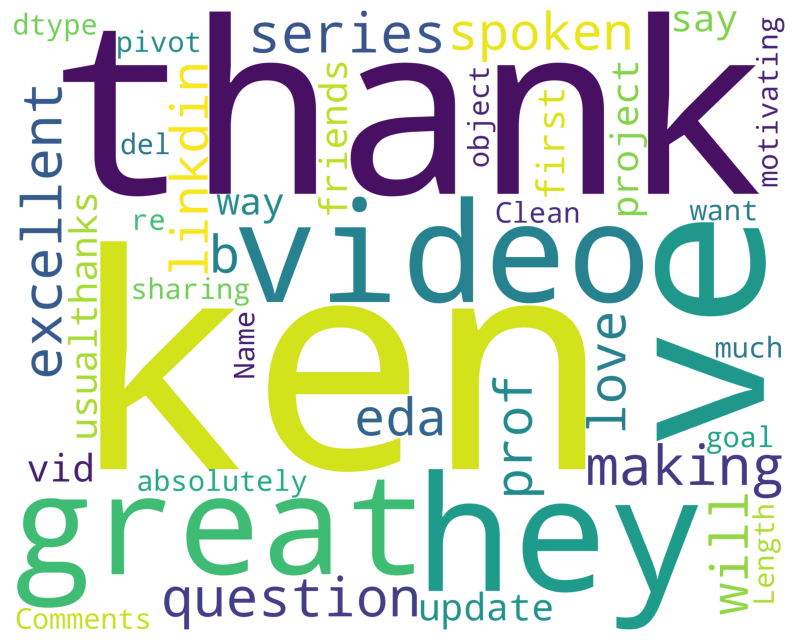

In [69]:
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 10px;
              color:white;">Words Used in Negative Comments
    
</h3>
</div>
    
</center>

In [70]:
wordcloud = WordCloud(width=2500, height=2000, max_words=50,
                      background_color='White').generate(str(Comments_df[(Comments_df['polarity'] < 0)].sample(100,
                     random_state=0)['Clean Comments']))

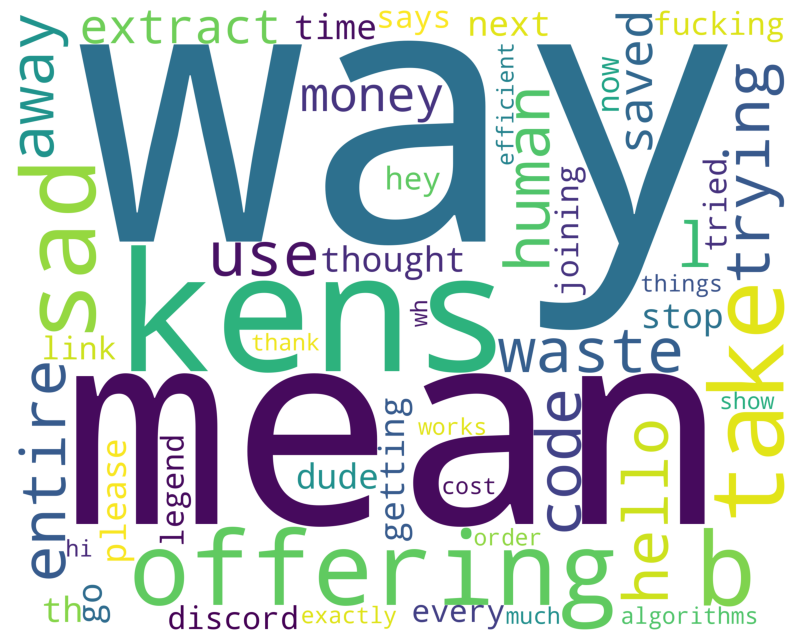

In [71]:
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumpurple;
           font-size:110%;
           letter-spacing:0.5px">

<h3 style="padding: 5px;
              color:white;">Most Commented Video
    
</h3>
</div>
    
</center>

In [72]:
topcommentsdf = pd.pivot_table(Comments_df, index = 'vidid', values = 'comment_id', aggfunc = 'count')
topcommentsdf = topcommentsdf.sort_values('comment_id', ascending = False)
New_df = topcommentsdf.merge(Aggregated_df,left_on='vidid', right_on='Video' )
New_df.groupby('Video title').sum().sort_values(by='comment_id',ascending= False).reset_index().head(5)

,Video title,comment_id,Video,Video pub­lish time,Com­ments ad­ded,Shares,Dis­likes,Likes,Sub­scribers lost,Sub­scribers gained,RPM (USD),CPM (USD),Av­er­age per­cent­age viewed (%),Av­er­age view dur­a­tion,Views,Watch time (hours),Sub­scribers,Your es­tim­ated rev­en­ue (USD),Im­pres­sions,Im­pres­sions click-through rate (%)
0,How I Would Learn Data Science (If I Had to St...,797,4OZip0cgOho,"May 8, 2020",907,9583,942,46903,451,46904,6.353,12.835,36.65,0:03:09,1253559,65850.7042,46453,7959.533,26498799,3.14
1,The Best Free Data Science Courses Nobody is T...,262,Ip50cXvpWY4,"Mar 9, 2020",294,4694,75,19464,131,10734,4.097,9.124,33.80,0:02:06,297222,10465.0467,10603,1217.046,4512254,3.24
2,Data Science Certificate vs Bootcamp vs Master...,224,Q9FjwzKFPuM,"Jan 18, 2020",239,456,48,2708,37,1576,8.315,17.543,36.21,0:05:53,92355,9057.2752,1539,767.493,2247912,2.78
3,How I Would Learn Data Science in 2021 (What H...,219,41Clrh6nv1s,"Dec 19, 2020",232,741,63,5869,57,3358,7.526,15.786,41.01,0:03:45,123515,7724.2735,3301,929.400,1699309,3.93
4,3 Proven Data Science Projects for Beginners (...,205,8igH8qZafpo,"Feb 17, 2020",220,1935,64,14708,72,9508,3.733,9.247,35.26,0:02:40,237467,10560.3597,9436,885.504,3137644,4.01


<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Q. What types of video titles and thumbnails drive the most traffic?
    
</h2>
</div>
    
</center>

In [73]:
df = Video_df[['Video Title','Thumbnail link', 'Average View Percentage','Average Watch Time']].copy()
df.sort_values(by='Average Watch Time',ascending= False).drop_duplicates('Video Title')['Video Title'].head(10).values.tolist()

['Ken Jee Q & A Live Stream (50,000 Sub Special!)',
 '100K Channel Update + AMA Stream!',
 'Data Science Explained with ... Cooking?',
 'Sports Analytics & Streaming Data Science on Twitch (Nick Wan) - KNN EP. 08',
 'Data Science Fundamentals: Data Cleaning in Python',
 'I Eat a Papaya Live on Stream (Plus Q&A for 150K Subs!)',
 'His Startup Will Land You a Data Science Job (Jeremie Harris) - KNN EP. 15',
 'The Data Science Interview: What to Expect',
 'Data Science Productivity, Motivation, and Organization (ft. Data Professor & Codebasics)',
 'Fast Cars to Faster Data (Alex Castrounis) - KNN EP. 12']


<center>
<div class="alert alert-block alert-info">
Video titles with words Live, Stream, Fundamentals and Data Science gets the most traffic


</div>
  </center>


<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:110%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Q. What types of videos have led to the most growth?
    
</h2>
</div>
    
</center>

In [74]:
df=Aggregated_df[['Video','Video title','Sub­scribers gained' ]].copy()
df.sort_values(by='Sub­scribers gained',ascending= False).drop([0]).head(5)['Video title'].values.tolist()

['How I Would Learn Data Science (If I Had to Start Over)',
 'The Best Free Data Science Courses Nobody is Talking About',
 '3 Proven Data Science Projects for Beginners (Kaggle)',
 'How I Would Learn Data Science in 2021 (What Has Changed?)',
 'Data Science Project from Scratch - Part 1 (Project Planning)']




<center>
<div class="alert alert-block alert-info">
Videos that led to the most growth of the channel are:-

</div>
  </center>

1. Data Science Roadmap,
2. Data Science Free Resources; and
3. Data Science Projects

In [75]:
# Install gradio (only first time)
!pip install gradio

import gradio as gr
import joblib # Changed from pickle to joblib

# -----------------------------
# Load model & vectorizer
# -----------------------------
with open("sentiment_model.pkl", "rb") as f:
    model = joblib.load(f) # Changed from pickle.load to joblib.load

with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = joblib.load(f) # Changed from pickle.load to joblib.load

# -----------------------------
# Prediction function
# -----------------------------
def predict_sentiment(text):
    if text.strip() == "":
        return "⚠️ Please enter a comment"

    try:
        transformed = vectorizer.transform([str(text)])
        prediction = model.predict(transformed)[0]

        # Debug (optional)
        print("Prediction:", prediction)

        # Adjust mapping if needed
        if prediction in [2]: # Positive was 2 in training
            return "😊 Positive Sentiment"
        elif prediction in [0]: # Negative was 0 in training
            return "😡 Negative Sentiment"
        elif prediction in [1]: # Neutral was 1 in training
            return "😐 Neutral Sentiment"
        else:
            return f"Unknown output: {prediction}"

    except Exception as e:
        return f"Error: {str(e)}"

# -----------------------------
# Gradio Interface
# -----------------------------
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter YouTube comment..."),
    outputs="text",
    title="🎥 YouTube Sentiment Analyzer",
    description="Analyze comments using your trained ML model"
)

# Launch inside notebook
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://68e69ce248cfa43af2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<a id = Section5></a>

<center>
<div style="color:;
           display:fill;
           border-radius:5px;
           background-color: mediumseagreen;
           font-size:180%;
           letter-spacing:0.5px">

<h2 style="padding: 10px;
              color:white;">Summary
    
</h2>
</div>
    
</center>

1.  The primary viewership for Ken's channel predominantly originates from the United States, India, and Great Britain, ranking as the top three countries of audience engagement.

2.  Topics related to "Data Science Roadmap" and "Data Science Projects" attract the highest number of views, indicating their popularity among viewers.

3.  Remarkable growth for the channel has been observed with videos focusing on "Data Science Free Resources" and "Data Science Roadmap," demonstrating their significant impact on channel expansion.

4.  Sentiment analysis of comments revealed a predominantly positive sentiment (around 70%) towards the videos, with a smaller percentage of negative and neutral comments.

5.  The BERT model was successfully integrated and demonstrated its capability to accurately predict sentiment scores (1-5) for comments, providing a powerful tool for understanding viewer feedback.

6.  Analysis of video titles and watch times suggests that content featuring "Live" streams, "Fundamentals," and general "Data Science" topics tends to drive the most traffic and engagement.

For more engaging content and interviews in the data field, don't forget to check out Ken Jee's YouTube channel at: https://www.youtube.com/c/KenJee1. Additionally, you can explore his insightful podcast, "Ken's Nearest Neighbors Podcast," where he interviews professionals in the data industry: https://www.youtube.com/c/KensNearestNeighborsPodcast.
